# 10. Ensembles: bagging, random forests and boosting

A single decision tree (notebook 9) is a wonderfully intuitive model — and a mediocre
predictor. It is *unstable*: move a handful of training points and the top split changes,
and with it the whole tree. Notebook 9 ended on exactly that observation, and this notebook
is the answer to it. The idea is almost embarrassingly simple:

> **Key idea.** Do not try to build one excellent model. Build *many* mediocre models and
> combine them. If their errors are not identical, the errors partially cancel and the
> combination is better than any of its members.

Turning that sentence into working algorithms produced two of the most successful families
in machine learning. **Bagging** and **random forests** (Breiman, 1996, 2001) build many
trees *in parallel* on perturbed versions of the data and average them; they attack
**variance**. **Boosting** (Freund & Schapire, 1997; Friedman, 2001) builds trees *in
sequence*, each one repairing the mistakes of the ensemble so far; it attacks **bias**. The
second family, in its modern gradient-boosting form, is the default model for tabular data
in 2020s practice: it wins most Kaggle competitions on tables, it is what you should try
first on a new spreadsheet-shaped problem, and it is still competitive with deep learning on
this kind of data (Grinsztajn, Oyallon & Varoquaux, 2022).

We will not just use these methods. We will *derive* why averaging helps (an exact formula
for the variance of a correlated average, verified numerically), implement bagging,
AdaBoost and gradient boosting from scratch in NumPy, check each one against scikit-learn,
and then spend the last third of the notebook on the three things that decide whether a
model works in practice: where it fails, what to tune, and how it behaves on real data.

**Prerequisites:** notebook 9 (decision trees — CART, impurity, pruning, and the
instability of a single tree), notebook 5 (generalisation, bias–variance, cross-validation)
and notebook 4 (pipelines and preprocessing). Notebook 12 (model selection) goes deeper into
the search strategies we use here; notebook 17 (interpretability) expands on permutation
importance and partial dependence.

## Learning objectives

After working through this notebook you will be able to

- explain *why* averaging helps, by deriving $\operatorname{Var}\big[\bar f\big] = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ for $B$ correlated predictors, and verify that formula on real ensembles;
- implement **bagging** from scratch, compute the **out-of-bag** error, and explain where the 36.8 % figure comes from;
- explain how a **random forest** decorrelates bagged trees with `max_features`, and read the resulting bias–variance trade-off off a validation curve;
- implement **AdaBoost** with decision stumps (SAMME reweighting) and reproduce scikit-learn's estimator weights exactly;
- derive **gradient boosting** as functional gradient descent, implement it for squared loss, and explain shrinkage, subsampling and early stopping;
- choose between `RandomForestClassifier`, `ExtraTrees*`, `GradientBoosting*` and `HistGradientBoosting*`, and say what XGBoost, LightGBM and CatBoost add;
- demonstrate the two classic failure modes — inability to extrapolate, and boosting's sensitivity to label noise — and say what to do about them;
- tune a random forest and a gradient-boosting model in the right order, using validation curves, a 2-D learning-rate × rounds heat-map and early stopping;
- run an honest end-to-end comparison (baseline, tree, forest, extra trees, boosting) with cross-validated means, standard errors and fit times.

## Setup

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score

from course_utils import set_style, PALETTE, plot_decision_boundary

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()

We will need one regression problem throughout the first half of the notebook. We use the
Friedman #1 function (Friedman, 1991), a standard benchmark with a non-linear interaction,
a quadratic term, two linear terms and three irrelevant features:

$$
y \;=\; 10\sin(\pi x_1 x_2) \;+\; 20\big(x_3 - \tfrac12\big)^2 \;+\; 10 x_4 \;+\; 5 x_5 \;+\; \varepsilon,
\qquad x_j \sim \mathcal{U}(0,1),\; \varepsilon \sim \mathcal{N}(0, \sigma^2).
$$

Because we generate it ourselves we know the truth, which is what makes the variance
experiments in section 1 possible. The *real*-data case study comes in section 11.

In [2]:
def make_friedman(n, d=8, noise=1.0, rng=rng):
    """Friedman #1 regression problem: 5 useful features, d-5 irrelevant ones."""
    X = rng.uniform(0, 1, size=(n, d))
    y = (10 * np.sin(np.pi * X[:, 0] * X[:, 1]) + 20 * (X[:, 2] - 0.5) ** 2
         + 10 * X[:, 3] + 5 * X[:, 4] + rng.normal(0, noise, n))
    return X, y

X_train, y_train = make_friedman(600)
X_test, y_test = make_friedman(2000)
print(f"train {X_train.shape}, test {X_test.shape};  Bayes MSE = noise variance = 1.0")
print(f"target: mean {y_train.mean():.2f}, sd {y_train.std():.2f}")

train (600, 8), test (2000, 8);  Bayes MSE = noise variance = 1.0
target: mean 14.40, sd 5.07


## 1. Why ensembles work

### 1.1 Wisdom of crowds: the Condorcet picture

Start with classification and the crudest possible combination rule: a **majority vote**.
Suppose $B$ classifiers each get the label right with probability $p$, independently of each
other. The number of correct votes is $\text{Binomial}(B, p)$, so the majority is right with
probability

$$
P(\text{majority correct}) \;=\; \sum_{k > B/2} \binom{B}{k} p^k (1-p)^{B-k}.
$$

The Condorcet jury theorem (1785) says this tends to $1$ as $B \to \infty$ whenever
$p > 1/2$ — and to $0$ whenever $p < 1/2$. Weak-but-better-than-chance voters become an
arbitrarily strong committee; weak-and-worse-than-chance voters become an arbitrarily
confident disaster.

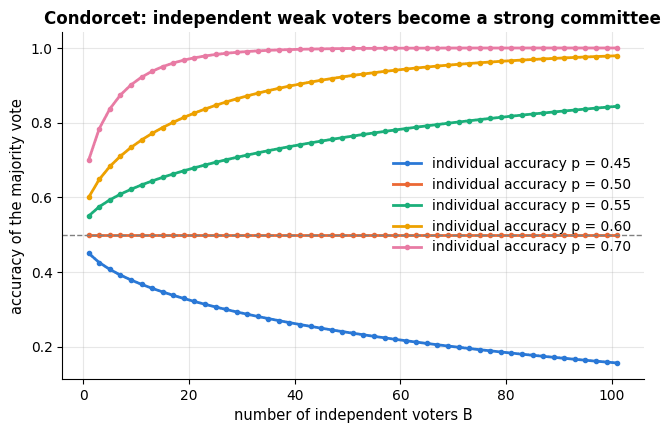

51 voters with p=0.55 vote correctly 0.764 of the time.


In [3]:
from scipy.stats import binom

Bs = np.arange(1, 102, 2)          # odd committee sizes, no ties
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for i, p in enumerate([0.45, 0.50, 0.55, 0.60, 0.70]):
    # P(more than B/2 correct) = survival function at floor(B/2)
    acc = binom.sf(Bs // 2, Bs, p)
    ax.plot(Bs, acc, marker="o", ms=3, color=PALETTE[i], label=f"individual accuracy p = {p:.2f}")
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xlabel("number of independent voters B")
ax.set_ylabel("accuracy of the majority vote")
ax.set_title("Condorcet: independent weak voters become a strong committee")
ax.legend(loc="center right")
plt.show()
print(f"51 voters with p=0.55 vote correctly {binom.sf(25, 51, 0.55):.3f} of the time.")

Eleven voters who are individually right 55 % of the time reach 63 %; fifty-one reach 76 %.
The catch is the word **independently**. Two decision trees fitted to the same data are very
far from independent — they make the *same* mistakes on the *same* hard points. Everything
that follows is about manufacturing disagreement without destroying accuracy.

### 1.2 The variance of an average of correlated predictors

The quantitative version of the argument is cleanest for regression. Let
$\hat f_1, \dots, \hat f_B$ be predictors that are identically distributed (over the
randomness of the training data and of the algorithm), each with variance
$\operatorname{Var}[\hat f_b(\mathbf{x})] = \sigma^2$ at a fixed input $\mathbf{x}$, and with
pairwise correlation $\operatorname{Corr}[\hat f_b(\mathbf{x}), \hat f_{b'}(\mathbf{x})] = \rho$
for $b \ne b'$. The ensemble is the average
$\bar f(\mathbf{x}) = \frac{1}{B}\sum_{b=1}^B \hat f_b(\mathbf{x})$. Then

$$
\operatorname{Var}\big[\bar f(\mathbf{x})\big]
= \frac{1}{B^2}\left[\sum_{b} \operatorname{Var}[\hat f_b] + \sum_{b \ne b'} \operatorname{Cov}[\hat f_b, \hat f_{b'}]\right]
= \frac{1}{B^2}\Big[B\sigma^2 + B(B-1)\rho\sigma^2\Big],
$$

and dividing through,

$$
\boxed{\;\operatorname{Var}\big[\bar f(\mathbf{x})\big] \;=\; \rho\,\sigma^2 \;+\; \frac{1-\rho}{B}\,\sigma^2\;}
$$

(Hastie, Tibshirani & Friedman, 2009, §15.2). Read this formula slowly, because the whole
notebook lives inside it:

- The second term $\frac{1-\rho}{B}\sigma^2$ **vanishes as $B \to \infty$**. Adding members
  is free variance reduction: more trees never hurt.
- The first term $\rho\sigma^2$ **does not depend on $B$**. It is a floor. No amount of
  averaging removes the variance that the members share.
- Therefore, once $B$ is large, the only way to improve an average is to **reduce $\rho$**
  (make the members disagree more) or **reduce $\sigma^2$** (make each member better) — and
  these usually pull in opposite directions. That trade-off *is* the `max_features`
  parameter of a random forest.
- The average is *unbiased relative to its members*: $\mathbb{E}[\bar f] = \mathbb{E}[\hat f_b]$.
  Averaging therefore changes variance only, and leaves **bias untouched**. Bagging a
  high-bias model is a waste of computation; this is why we bag *deep, unpruned* trees,
  which have low bias and high variance.

> **Why it matters.** The formula splits the ensemble design problem into two independent
> questions — "how good is one member?" and "how much do members disagree?" — and every
> parallel ensemble method in this notebook is an answer to the second.

### 1.3 Verifying the formula numerically

A formula you have not checked is a formula you do not believe. We measure all three
quantities directly. The randomness we average over is the draw of the **training set**:
we create 60 parallel "worlds", each with its own training sample of 200 points, and in each
world we grow $B = 30$ unpruned trees on bootstrap resamples. Two trees in the same world are
correlated because they share a training set; that shared randomness is exactly $\rho$.

In [4]:
n_worlds, B, n_tr = 60, 30, 200
X_eval, _ = make_friedman(40)                 # fixed evaluation points
preds = np.zeros((n_worlds, B, len(X_eval)))  # (world, tree, eval point)

t0 = time.perf_counter()
for s in range(n_worlds):
    Xs, ys = make_friedman(n_tr)                              # a fresh world
    for b in range(B):
        idx = rng.integers(0, n_tr, n_tr)                     # bootstrap resample
        tree = DecisionTreeRegressor(random_state=b).fit(Xs[idx], ys[idx])
        preds[s, b] = tree.predict(X_eval)
print(f"{n_worlds * B} trees fitted in {time.perf_counter() - t0:.1f}s")

sigma2 = preds.var(axis=0, ddof=1).mean()          # variance of ONE tree, averaged over b and x
rho = np.mean([np.corrcoef(preds[:, :, j].T)[np.triu_indices(B, 1)].mean()
               for j in range(len(X_eval))])       # mean pairwise correlation across worlds
print(f"single-tree variance  sigma^2 = {sigma2:.3f}")
print(f"mean tree-pair correlation rho = {rho:.3f}")
print(f"variance floor rho*sigma^2     = {rho * sigma2:.3f}  (unreachable by averaging)")

1800 trees fitted in 2.2s
single-tree variance  sigma^2 = 10.748
mean tree-pair correlation rho = 0.115
variance floor rho*sigma^2     = 1.232  (unreachable by averaging)


Now compare the *measured* variance of the ensemble average against the *predicted*
$\rho\sigma^2 + (1-\rho)\sigma^2/B$, as a function of $B$.

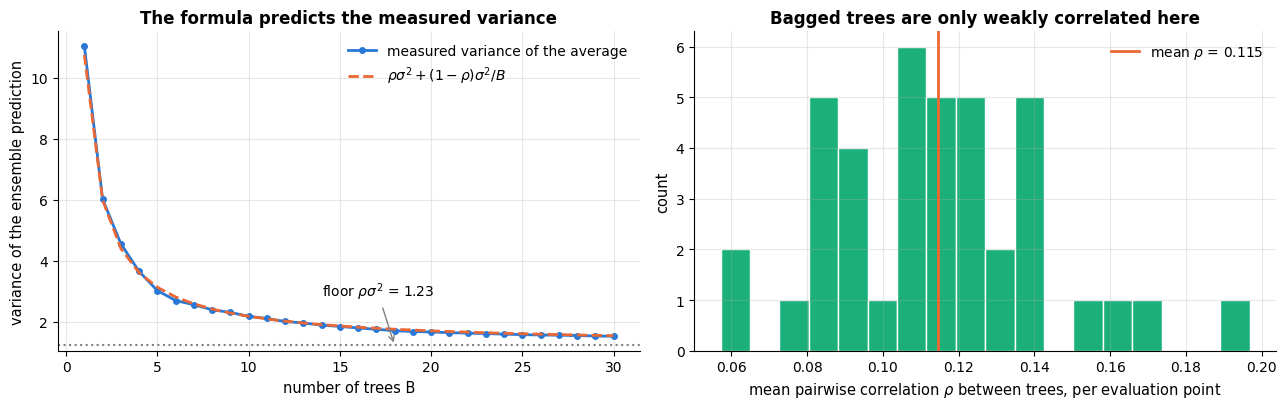

B=30: measured 1.531 vs formula 1.549 (relative error 1.2%)


In [5]:
B_grid = np.arange(1, B + 1)
measured = np.array([preds[:, :b].mean(axis=1).var(axis=0, ddof=1).mean() for b in B_grid])
formula = rho * sigma2 + (1 - rho) * sigma2 / B_grid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(B_grid, measured, marker="o", ms=4, color=PALETTE[0], label="measured variance of the average")
ax.plot(B_grid, formula, color=PALETTE[1], ls="--", label=r"$\rho\sigma^2 + (1-\rho)\sigma^2/B$")
ax.axhline(rho * sigma2, color="gray", ls=":", lw=1.5)
ax.annotate(f"floor $\\rho\\sigma^2$ = {rho * sigma2:.2f}", xy=(18, rho * sigma2),
            xytext=(14, rho * sigma2 + 1.6), arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("number of trees B")
ax.set_ylabel("variance of the ensemble prediction")
ax.set_title("The formula predicts the measured variance")
ax.legend()

ax = axes[1]
pair_rhos = [np.corrcoef(preds[:, :, j].T)[np.triu_indices(B, 1)].mean() for j in range(len(X_eval))]
ax.hist(pair_rhos, bins=18, color=PALETTE[2], edgecolor="white")
ax.axvline(rho, color=PALETTE[1], lw=2, label=f"mean $\\rho$ = {rho:.3f}")
ax.set_xlabel(r"mean pairwise correlation $\rho$ between trees, per evaluation point")
ax.set_ylabel("count")
ax.set_title("Bagged trees are only weakly correlated here")
ax.legend()
plt.tight_layout()
plt.show()
print(f"B=30: measured {measured[-1]:.3f} vs formula {formula[-1]:.3f} "
      f"(relative error {abs(measured[-1] - formula[-1]) / formula[-1]:.1%})")

The dashed curve lies on top of the measured points: the derivation is not a heuristic, it
is an identity. Note also the shape — most of the benefit arrives in the first ten members,
and after that we are grinding towards the floor $\rho\sigma^2$.

### 1.4 Two ways to build an ensemble

The formula also explains the two great families, which differ in *what* they attack:

| | **Parallel / averaging** | **Sequential / boosting** |
|---|---|---|
| Members are built | independently, on perturbed data | one after another, each fitting what is left over |
| Members are | deep, low-bias, high-variance | shallow, high-bias, low-variance ("weak learners") |
| Combination | plain (weighted) average or vote | additive sum, usually shrunk by $\eta$ |
| Attacks | **variance** | **bias** (and, with shrinkage, variance too) |
| More members | never hurts (curve plateaus) | eventually **overfits** — needs early stopping |
| Parallelises | perfectly (`n_jobs`) | only within a tree |
| Examples | bagging, random forest, extra trees | AdaBoost, gradient boosting, XGBoost |

A third family — **stacking** — learns the combination rule itself (section 8).

Let us see the claim "bagging removes variance, boosting removes bias" as a measurement
rather than an assertion, reusing the many-worlds machinery of section 1.3 on a smaller
scale.

In [6]:
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor

n_worlds2, n_tr2 = 40, 300
X_ev, y_ev_clean = make_friedman(300, noise=0.0)      # noise-free truth at the eval points
models = {
    "single deep tree": lambda: DecisionTreeRegressor(random_state=RANDOM_STATE),
    "bagging (50 trees)": lambda: BaggingRegressor(n_estimators=50, random_state=RANDOM_STATE),
    "boosting (200 stumps)": lambda: GradientBoostingRegressor(n_estimators=200, max_depth=2,
                                                               learning_rate=0.1, random_state=RANDOM_STATE),
}
rows = []
for name, make in models.items():
    P = np.zeros((n_worlds2, len(X_ev)))
    for s in range(n_worlds2):
        Xs, ys = make_friedman(n_tr2)
        P[s] = make().fit(Xs, ys).predict(X_ev)
    bias2 = np.mean((P.mean(axis=0) - y_ev_clean) ** 2)
    var = np.mean(P.var(axis=0))
    rows.append({"model": name, "bias^2": bias2, "variance": var, "bias^2 + variance": bias2 + var})
bv = pd.DataFrame(rows).set_index("model")
bv.round(3)

,bias^2,variance,bias^2 + variance
model,,,
single deep tree,3.113,8.274,11.387
bagging (50 trees),3.314,1.158,4.472
boosting (200 stumps),1.453,0.984,2.437


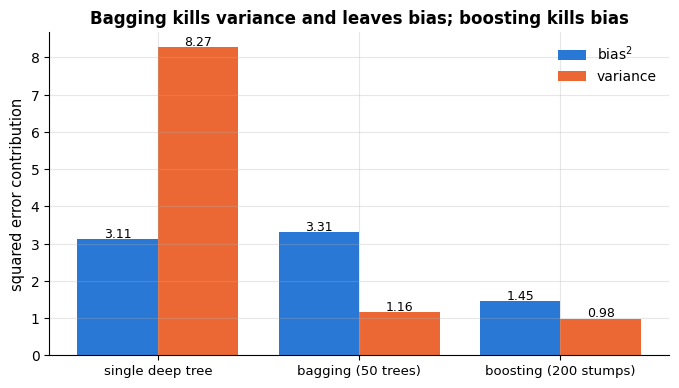

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
idx = np.arange(len(bv))
ax.bar(idx - 0.2, bv["bias^2"], width=0.4, color=PALETTE[0], label="bias$^2$")
ax.bar(idx + 0.2, bv["variance"], width=0.4, color=PALETTE[1], label="variance")
for i, (b, v) in enumerate(zip(bv["bias^2"], bv["variance"])):
    ax.text(i - 0.2, b + 0.05, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + 0.2, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
ax.set_xticks(idx)
ax.set_xticklabels(bv.index, fontsize=9.5)
ax.set_ylabel("squared error contribution")
ax.set_title("Bagging kills variance and leaves bias; boosting kills bias")
ax.legend()
plt.show()

Bagging leaves the bias of a deep tree almost unchanged while cutting its variance by an
order of magnitude. Boosting starts from a *biased* weak learner (depth-2 stumps) and drives
the bias down instead. Both end up far below the single tree — by different routes.

## 2. Bagging

### 2.1 The bootstrap, and the algorithm

**Bootstrap aggregating** (Breiman, 1996) needs one ingredient: the bootstrap
(Efron, 1979). A *bootstrap sample* of a dataset $\mathcal{D}$ of size $n$ is a sample of
size $n$ drawn **with replacement** from $\mathcal{D}$. It looks like a dataset from the same
distribution, but it is not the same dataset — roughly a third of the original points are
missing and others appear two or three times. That is the perturbation that makes trees
disagree.

> **Algorithm (bagging).** Given $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$ and a base
> learner:
> 1. For $b = 1, \dots, B$: draw a bootstrap sample $\mathcal{D}^{(b)}$ of size $n$ from
>    $\mathcal{D}$, and fit $\hat f_b$ on $\mathcal{D}^{(b)}$.
> 2. Predict by averaging: $\bar f(\mathbf{x}) = \frac1B \sum_b \hat f_b(\mathbf{x})$ for
>    regression; by majority vote (or by averaging the class probabilities, "soft voting")
>    for classification.

Nothing in the algorithm is specific to trees, but trees are the ideal base learner: they
are high-variance (so there is a lot to remove), low-bias when grown deep (so the average is
not biased), and fast to fit.

### 2.2 Bagging from scratch

The implementation is thirty lines. We write it so that it *also* covers random forests:
passing `max_features=m` makes each tree consider a random subset of $m$ features at every
split, which is the only difference between bagging and a random forest (section 3).
While fitting we record which samples were left out of each bootstrap sample — that gives
us the out-of-bag error in section 2.5 for free.

In [8]:
class BaggedTrees:
    """Bagging of regression trees, from scratch. max_features < d turns it into a random forest."""

    def __init__(self, n_estimators=100, max_features=None, max_depth=None, random_state=0):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        n = len(y)
        boot_rng = np.random.default_rng(self.random_state)
        self.trees_, oob_masks = [], []
        for b in range(self.n_estimators):
            idx = boot_rng.integers(0, n, n)              # bootstrap: n draws WITH replacement
            tree = DecisionTreeRegressor(max_features=self.max_features, max_depth=self.max_depth,
                                         random_state=self.random_state + b)
            self.trees_.append(tree.fit(X[idx], y[idx]))
            mask = np.ones(n, dtype=bool)
            mask[idx] = False                             # True = this sample is out-of-bag for tree b
            oob_masks.append(mask)
        self.oob_masks_ = np.array(oob_masks)
        # out-of-bag prediction: for each sample, average only the trees that never saw it
        total, count = np.zeros(n), np.zeros(n)
        for tree, mask in zip(self.trees_, self.oob_masks_):
            total[mask] += tree.predict(X[mask])
            count[mask] += 1
        self.oob_prediction_ = np.where(count > 0, total / np.maximum(count, 1), y.mean())
        self.oob_score_ = r2_score(y, self.oob_prediction_)
        return self

    def predict(self, X, n_estimators=None):
        m = n_estimators or self.n_estimators
        return np.mean([t.predict(np.asarray(X)) for t in self.trees_[:m]], axis=0)

Now the check that matters: does it agree with scikit-learn?

In [9]:
from sklearn.ensemble import RandomForestRegressor

single = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
mine = BaggedTrees(n_estimators=100, random_state=RANDOM_STATE).fit(X_train, y_train)
sk_bag = BaggingRegressor(DecisionTreeRegressor(random_state=RANDOM_STATE), n_estimators=100,
                          oob_score=True, random_state=RANDOM_STATE).fit(X_train, y_train)
mine_rf = BaggedTrees(n_estimators=100, max_features=3, random_state=RANDOM_STATE).fit(X_train, y_train)
sk_rf = RandomForestRegressor(n_estimators=100, max_features=3, oob_score=True,
                              random_state=RANDOM_STATE).fit(X_train, y_train)

rows = []
for name, m in [("single unpruned tree", single), ("BaggedTrees (ours)", mine),
                ("BaggingRegressor (sklearn)", sk_bag),
                ("BaggedTrees, max_features=3 (ours)", mine_rf),
                ("RandomForestRegressor (sklearn)", sk_rf)]:
    rows.append({"model": name,
                 "test MSE": mean_squared_error(y_test, m.predict(X_test)),
                 "OOB R^2": getattr(m, "oob_score_", np.nan)})
pd.DataFrame(rows).set_index("model").round(3)

,test MSE,OOB R^2
model,,
single unpruned tree,10.037,NaN
BaggedTrees (ours),4.426,0.821
BaggingRegressor (sklearn),4.393,0.823
"BaggedTrees, max_features=3 (ours)",4.434,0.820
RandomForestRegressor (sklearn),4.420,0.828


Our implementation and scikit-learn's land within a percent of each other — the residual
difference is only the particular bootstrap draws, which use different random streams.
Bagging cuts the test MSE of a single tree by more than half — from about 10 to about 4.4 —
and the out-of-bag $R^2$ lands close to the test performance (more on that in section 2.5).
Note that on *this* problem restricting `max_features` to 3 changes nothing: with only five
relevant features out of eight, there is little redundancy to exploit. Section 3 builds a
problem where it matters.

### 2.3 Seeing the averaging

The clearest picture of bagging is a 2-D classification problem. Each individual bootstrap
tree carves the plane into a jagged, over-confident partition; the average of many of them is
smooth and sensible.

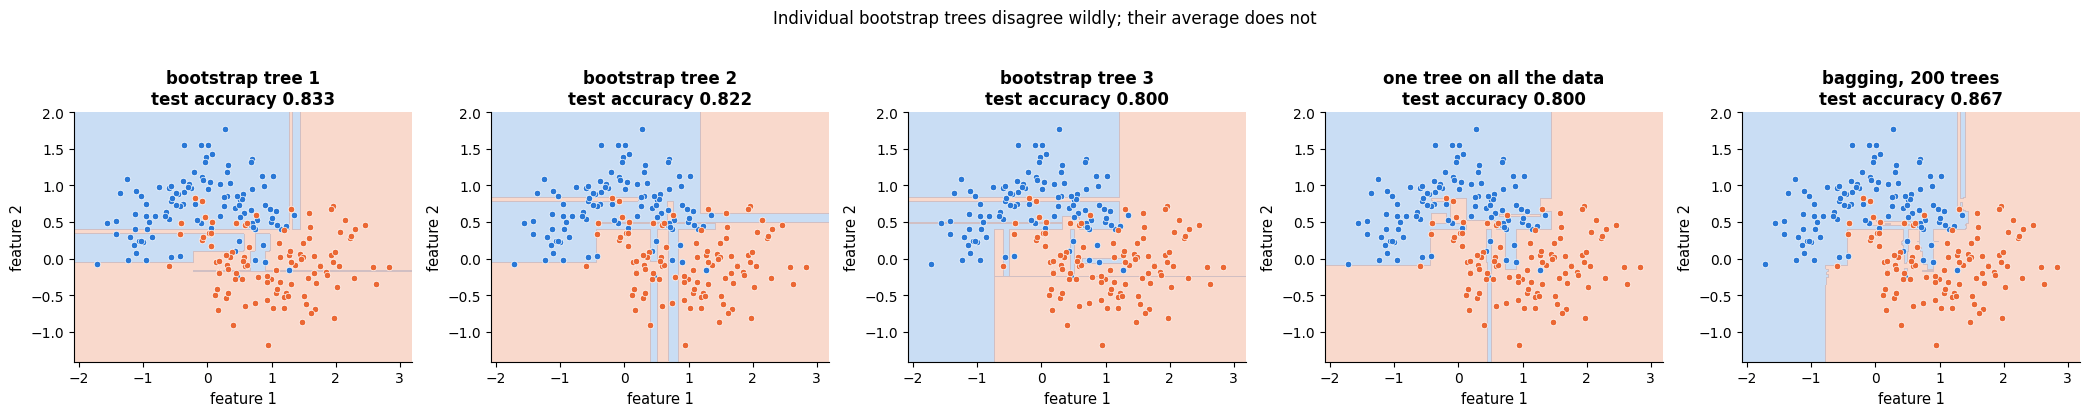

In [10]:
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

X_moon, y_moon = make_moons(n_samples=300, noise=0.30, random_state=RANDOM_STATE)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_moon, y_moon, test_size=0.3, stratify=y_moon,
                                              random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 5, figsize=(21, 4.0))
boot_rng = np.random.default_rng(RANDOM_STATE)
for k in range(3):                                   # three individual bootstrap trees
    idx = boot_rng.integers(0, len(ym_tr), len(ym_tr))
    t = DecisionTreeClassifier(random_state=k).fit(Xm_tr[idx], ym_tr[idx])
    plot_decision_boundary(t, Xm_tr, ym_tr, ax=axes[k],
                           title=f"bootstrap tree {k + 1}\ntest accuracy {t.score(Xm_te, ym_te):.3f}")
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xm_tr, ym_tr)
plot_decision_boundary(full_tree, Xm_tr, ym_tr, ax=axes[3],
                       title=f"one tree on all the data\ntest accuracy {full_tree.score(Xm_te, ym_te):.3f}")
bag = BaggingClassifier(DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=200,
                        random_state=RANDOM_STATE).fit(Xm_tr, ym_tr)
plot_decision_boundary(bag, Xm_tr, ym_tr, ax=axes[4],
                       title=f"bagging, 200 trees\ntest accuracy {bag.score(Xm_te, ym_te):.3f}")
for ax in axes:
    ax.legend().set_visible(False)
fig.suptitle("Individual bootstrap trees disagree wildly; their average does not", y=1.03)
plt.tight_layout()
plt.show()

The individual trees differ dramatically from panel to panel — that is the instability
notebook 9 warned about, and here it is a *feature*: disagreement is what makes $\rho$ small.
The bagged boundary keeps the overall shape while discarding the islands and spikes that each
single tree invented from noise.

### 2.4 How many trees?

The formula says the test error should fall and then flatten. Let us watch it happen, using
the `n_estimators` argument of our `predict` so that we reuse the same fitted trees.

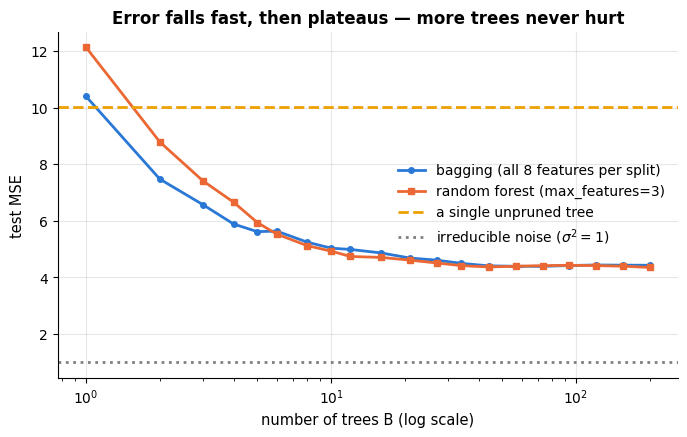

single tree: 10.037   B=10: 5.035   B=200: 4.430


In [11]:
n_grid = np.unique(np.round(np.logspace(0, np.log10(200), 22)).astype(int))
bag200 = BaggedTrees(n_estimators=200, random_state=RANDOM_STATE).fit(X_train, y_train)
rf200 = BaggedTrees(n_estimators=200, max_features=3, random_state=RANDOM_STATE).fit(X_train, y_train)
mse_bag = [mean_squared_error(y_test, bag200.predict(X_test, b)) for b in n_grid]
mse_rf = [mean_squared_error(y_test, rf200.predict(X_test, b)) for b in n_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_grid, mse_bag, marker="o", ms=4, color=PALETTE[0], label="bagging (all 8 features per split)")
ax.plot(n_grid, mse_rf, marker="s", ms=4, color=PALETTE[1], label="random forest (max_features=3)")
ax.axhline(mean_squared_error(y_test, single.predict(X_test)), color=PALETTE[3], ls="--",
           label="a single unpruned tree")
ax.axhline(1.0, color="gray", ls=":", label="irreducible noise ($\\sigma^2 = 1$)")
ax.set_xscale("log")
ax.set_xlabel("number of trees B (log scale)")
ax.set_ylabel("test MSE")
ax.set_title("Error falls fast, then plateaus — more trees never hurt")
ax.legend()
plt.show()
near10 = int(np.argmin(np.abs(n_grid - 10)))
print(f"single tree: {mean_squared_error(y_test, single.predict(X_test)):.3f}   "
      f"B={n_grid[near10]}: {mse_bag[near10]:.3f}   B=200: {mse_bag[-1]:.3f}")

> **Key idea.** `n_estimators` is *not* a bias–variance knob for bagging-type ensembles: the
> curve is monotone and flattens. Choose it by your compute budget, not by cross-validation.
> This is the opposite of boosting, where the number of rounds is *the* critical
> hyper-parameter (section 6).

### 2.5 Out-of-bag error: a free validation set

Each bootstrap sample leaves some training points untouched. How many? The probability that
a particular sample $i$ is *not* chosen in one of the $n$ draws is $1 - 1/n$, and the draws
are independent, so

$$
P\big(i \notin \mathcal{D}^{(b)}\big) \;=\; \Big(1 - \frac1n\Big)^{n} \;\xrightarrow[n \to \infty]{}\; e^{-1} \;\approx\; 0.368 .
$$

(The limit is the definition of $e$: $\lim_{n\to\infty}(1 - 1/n)^n = e^{-1}$.) So about
**36.8 %** of the data is out-of-bag for every tree — a held-out set that costs nothing.
Averaging, for each sample $i$, only over the trees for which $i$ was out-of-bag gives the
**out-of-bag prediction**, and its error is an almost-unbiased estimate of test error
(Breiman, 1996). Let us confirm the 36.8 % by simulation first.

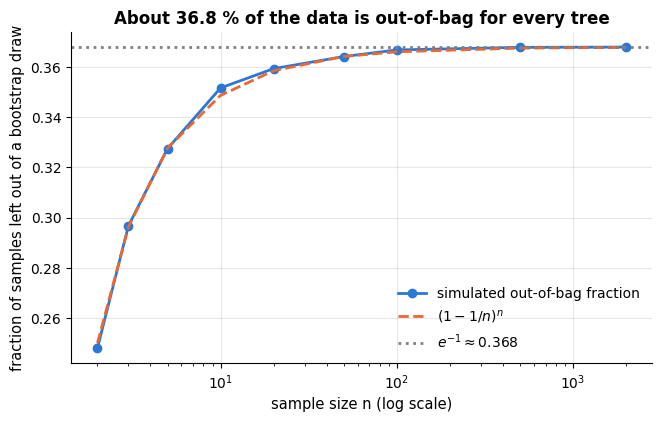

n=2000: simulated 0.3679, formula 0.3678, limit 0.3679
our fitted forest: mean OOB fraction = 0.3668


In [12]:
sizes = np.array([2, 3, 5, 10, 20, 50, 100, 500, 2000])
emp = []
for n in sizes:
    draws = rng.integers(0, n, size=(4000, n))                    # 4000 bootstrap samples
    emp.append(np.mean([len(np.setdiff1d(np.arange(n), d)) / n for d in draws]))

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(sizes, emp, marker="o", color=PALETTE[0], label="simulated out-of-bag fraction")
ax.plot(sizes, (1 - 1 / sizes) ** sizes, ls="--", color=PALETTE[1], label=r"$(1 - 1/n)^n$")
ax.axhline(np.exp(-1), color="gray", ls=":", label=r"$e^{-1} \approx 0.368$")
ax.set_xscale("log")
ax.set_xlabel("sample size n (log scale)")
ax.set_ylabel("fraction of samples left out of a bootstrap draw")
ax.set_title("About 36.8 % of the data is out-of-bag for every tree")
ax.legend()
plt.show()
print(f"n=2000: simulated {emp[-1]:.4f}, formula {(1 - 1/2000)**2000:.4f}, limit {np.exp(-1):.4f}")
print(f"our fitted forest: mean OOB fraction = {mine.oob_masks_.mean():.4f}")

The simulation, the closed form and $e^{-1}$ agree to three decimals, and the masks recorded
by our own implementation show the same fraction. Now the practical payoff: OOB error tracks
test error as trees are added, so it can replace a validation split entirely.

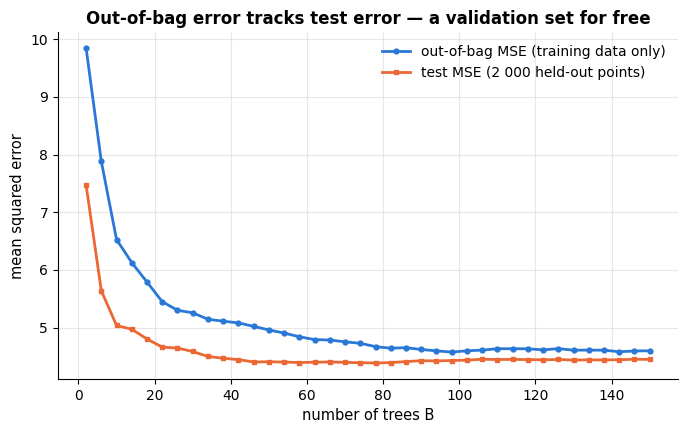

final OOB MSE 4.597 vs test MSE 4.447


In [13]:
bag_oob = BaggedTrees(n_estimators=150, random_state=RANDOM_STATE).fit(X_train, y_train)
n_grid2 = np.arange(2, 151, 4)
oob_curve, test_curve = [], []
for b in n_grid2:                                  # recompute the OOB prediction from the first b trees
    total, count = np.zeros(len(y_train)), np.zeros(len(y_train))
    for tree, mask in zip(bag_oob.trees_[:b], bag_oob.oob_masks_[:b]):
        total[mask] += tree.predict(X_train[mask])
        count[mask] += 1
    ok = count > 0
    oob_curve.append(mean_squared_error(y_train[ok], total[ok] / count[ok]))
    test_curve.append(mean_squared_error(y_test, bag_oob.predict(X_test, b)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_grid2, oob_curve, marker="o", ms=3.5, color=PALETTE[0], label="out-of-bag MSE (training data only)")
ax.plot(n_grid2, test_curve, marker="s", ms=3.5, color=PALETTE[1], label="test MSE (2 000 held-out points)")
ax.set_xlabel("number of trees B")
ax.set_ylabel("mean squared error")
ax.set_title("Out-of-bag error tracks test error — a validation set for free")
ax.legend()
plt.show()
print(f"final OOB MSE {oob_curve[-1]:.3f} vs test MSE {test_curve[-1]:.3f}")

> **Warning.** OOB error is slightly *pessimistic* for small $B$: with only a few trees, each
> sample's OOB prediction averages just a handful of members, so it behaves like a much
> smaller ensemble. Use it for $B \gtrsim 100$, and prefer proper cross-validation when you
> are comparing models rather than monitoring one. OOB error is also unavailable once you
> wrap the forest in a `Pipeline` with fitted preprocessing steps — the OOB samples have then
> already influenced the transformer.

## 3. Random forests

### 3.1 Decorrelating the trees

Look again at $\operatorname{Var}[\bar f] = \rho\sigma^2 + (1-\rho)\sigma^2/B$. With
$B = 200$ the second term is negligible, and we are stuck at $\rho\sigma^2$. Bagged trees
are correlated for a simple reason: they are all fitted by the *same greedy algorithm* to
*mostly the same data*, so they all discover the same dominant split first, and the same
second split, and so on.

Breiman's (2001) fix — anticipated by Ho's (1998) random subspace method and by Amit &
Geman's randomised features — is to inject randomness *into the tree-growing algorithm*:

> **Algorithm (random forest).** For $b = 1,\dots,B$: draw a bootstrap sample; grow a tree,
> but **at every node**, choose the split from a fresh random subset of $m \le d$ features
> (`max_features`) instead of from all $d$. Average / vote as in bagging.

Restricting the feature set forces trees down different paths. Each individual tree gets
*worse* ($\sigma^2$ goes up, and so does its bias), but $\rho$ goes down — and if $\rho$
falls faster than $\sigma^2$ rises, the ensemble improves. This is the trade-off, and it has
a sweet spot.

### 3.2 Watching $\rho$ fall

To see the trade-off we need features that carry overlapping information, which is the
normal situation in real tabular data. We build a problem with $d = 20$ compound-symmetric
correlated features (all pairs correlated at $\approx 0.75$) of which ten drive the target.

In [14]:
def make_correlated(n, d=20, corr=0.75, rng=rng):
    """d correlated predictors (compound symmetry); the target uses ten of them plus a kink."""
    z = rng.normal(size=(n, 1))
    X = np.sqrt(corr) * z + np.sqrt(1 - corr) * rng.normal(size=(n, d))
    y = X[:, :10].sum(axis=1) + 2.0 * np.sin(2 * X[:, 0]) + rng.normal(0, 1.5, n)
    return X, y

Xc, yc = make_correlated(700)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=RANDOM_STATE)

mf_grid = [1, 2, 3, 5, 8, 13, 20]
rows = []
for mf in mf_grid:
    forest = RandomForestRegressor(n_estimators=150, max_features=mf, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    P = np.array([t.predict(Xc_te) for t in forest.estimators_])          # (B, n_test)
    rho_hat = np.corrcoef(P)[np.triu_indices(len(P), 1)].mean()
    rows.append({"max_features": mf, "rho (tree pairs)": rho_hat,
                 "single-tree MSE": np.mean([mean_squared_error(yc_te, p) for p in P]),
                 "forest MSE": mean_squared_error(yc_te, forest.predict(Xc_te))})
mf_df = pd.DataFrame(rows).set_index("max_features")
mf_df.round(3)

,rho (tree pairs),single-tree MSE,forest MSE
max_features,,,
1,0.822,19.268,4.705
2,0.841,17.113,4.315
3,0.850,15.987,3.924
5,0.864,14.606,3.684
8,0.875,13.477,3.467
13,0.884,12.845,3.540
20,0.894,12.340,3.918


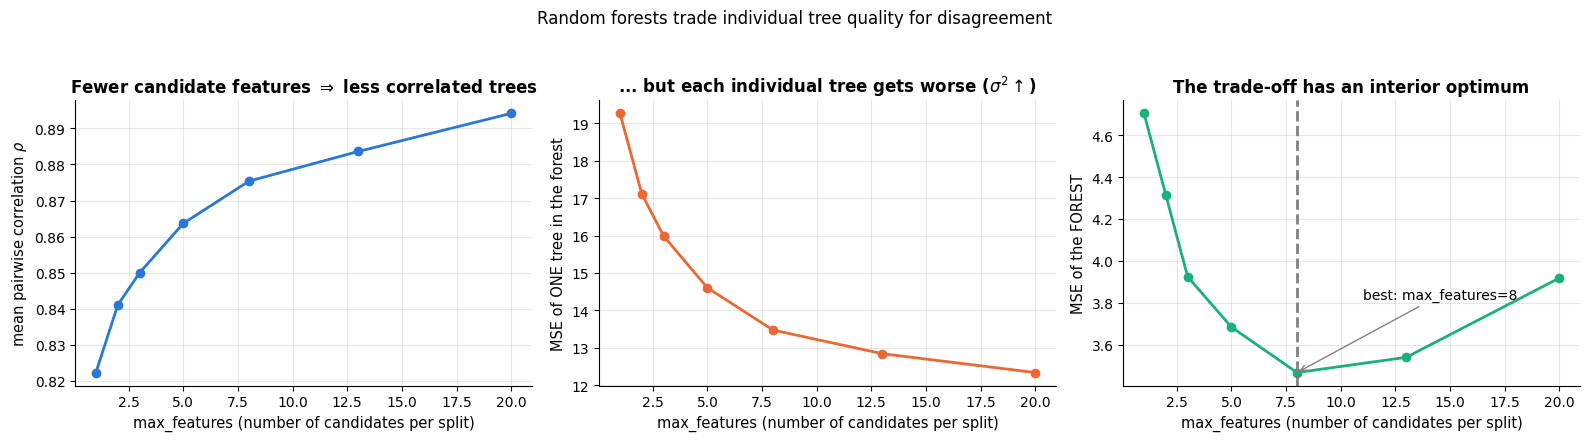

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(mf_df.index, mf_df["rho (tree pairs)"], marker="o", color=PALETTE[0])
axes[0].set_ylabel(r"mean pairwise correlation $\rho$")
axes[0].set_title(r"Fewer candidate features $\Rightarrow$ less correlated trees")
axes[1].plot(mf_df.index, mf_df["single-tree MSE"], marker="o", color=PALETTE[1])
axes[1].set_ylabel("MSE of ONE tree in the forest")
axes[1].set_title(r"... but each individual tree gets worse ($\sigma^2 \uparrow$)")
axes[2].plot(mf_df.index, mf_df["forest MSE"], marker="o", color=PALETTE[2])
best_mf = mf_df["forest MSE"].idxmin()
axes[2].axvline(best_mf, color="gray", ls="--")
axes[2].annotate(f"best: max_features={best_mf}", xy=(best_mf, mf_df["forest MSE"].min()),
                 xytext=(best_mf + 3, mf_df["forest MSE"].min() + 0.35),
                 arrowprops=dict(arrowstyle="->", color="gray"))
axes[2].set_ylabel("MSE of the FOREST")
axes[2].set_title("The trade-off has an interior optimum")
for ax in axes:
    ax.set_xlabel("max_features (number of candidates per split)")
fig.suptitle("Random forests trade individual tree quality for disagreement", y=1.04)
plt.tight_layout()
plt.show()

Three panels, one story, and it is the variance formula made visible. Going from
`max_features=20` (plain bagging) to `max_features=1` drops $\rho$ steadily; the individual
trees get steadily worse; the forest error is a compromise that bottoms out somewhere in the
middle.

> **Defaults.** scikit-learn uses `max_features="sqrt"` ($\lfloor\sqrt d\rfloor$) for
> classification and `max_features=1.0` (all features) for regression. Those are reasonable
> starting points — Breiman's original recommendations — but `max_features` is the one
> forest parameter genuinely worth tuning (section 10).

### 3.3 Extremely randomised trees

Geurts, Ernst & Wehenkel (2006) push the randomisation one step further. In an **extra-trees**
ensemble, for each of the `max_features` candidate features the algorithm does not search for
the best threshold — it draws **one threshold at random** and keeps the best of those random
splits. Two consequences:

- Fitting is much faster: no sorting of feature values, no scan over candidate thresholds.
- Trees are even more decorrelated ($\rho$ lower still), at the price of more bias per tree.
  To compensate, extra trees are by default fitted on the **whole training set**
  (`bootstrap=False`) rather than on bootstrap samples.

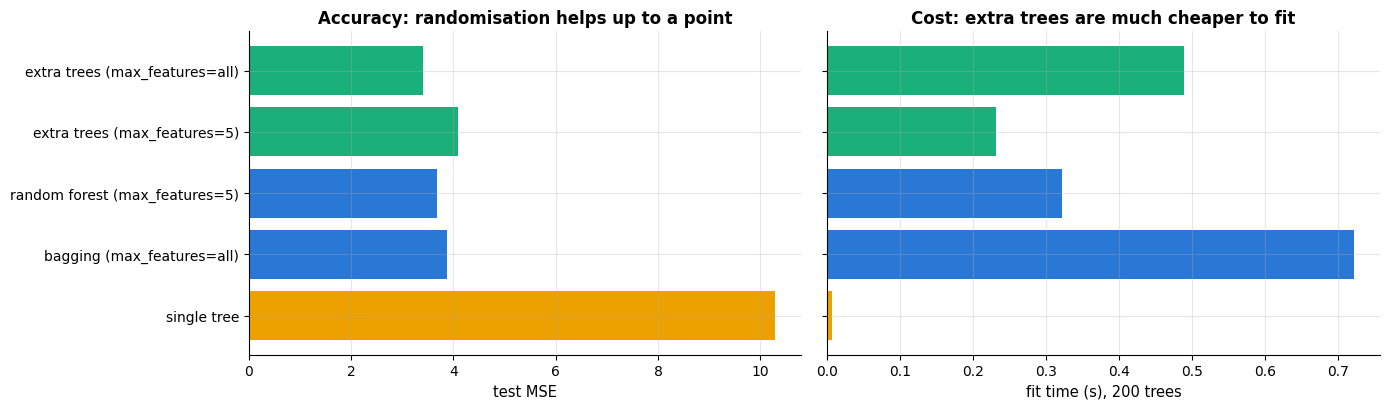

,test MSE,fit time (s)
model,,
single tree,10.289,0.006
bagging (max_features=all),3.885,0.721
random forest (max_features=5),3.677,0.322
extra trees (max_features=5),4.095,0.231
extra trees (max_features=all),3.400,0.490


In [16]:
from sklearn.ensemble import ExtraTreesRegressor

rows = []
for name, model in [
    ("single tree", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ("bagging (max_features=all)", RandomForestRegressor(n_estimators=200, max_features=None, random_state=RANDOM_STATE)),
    ("random forest (max_features=5)", RandomForestRegressor(n_estimators=200, max_features=5, random_state=RANDOM_STATE)),
    ("extra trees (max_features=5)", ExtraTreesRegressor(n_estimators=200, max_features=5, random_state=RANDOM_STATE)),
    ("extra trees (max_features=all)", ExtraTreesRegressor(n_estimators=200, max_features=None, random_state=RANDOM_STATE)),
]:
    t0 = time.perf_counter()
    model.fit(Xc_tr, yc_tr)
    fit_s = time.perf_counter() - t0
    rows.append({"model": name, "test MSE": mean_squared_error(yc_te, model.predict(Xc_te)),
                 "fit time (s)": fit_s})
et_df = pd.DataFrame(rows).set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
colors = [PALETTE[3]] + [PALETTE[0]] * 2 + [PALETTE[2]] * 2
axes[0].barh(et_df.index, et_df["test MSE"], color=colors)
axes[0].set_xlabel("test MSE")
axes[0].set_title("Accuracy: randomisation helps up to a point")
axes[1].barh(et_df.index, et_df["fit time (s)"], color=colors)
axes[1].set_xlabel("fit time (s), 200 trees")
axes[1].set_title("Cost: extra trees are much cheaper to fit")
axes[1].tick_params(labelleft=False)
plt.tight_layout()
plt.show()
et_df.round(3)

Read the two panels together. On this problem the best model is *extra trees using all the
features* — better than any forest here and still faster to fit than plain bagging, because
choosing a random threshold is so much cheaper than searching for the best one. Note also that
extra trees with `max_features=5` are *worse* than a random forest with the same setting: the
two sources of randomness compound, and the ensemble ends up over-randomised. That is the
general rule — **extra trees want a larger `max_features` than a random forest does**, because
the random thresholds already supply the decorrelation. They are always worth trying alongside
a forest: they cost a fraction of the time, and on noisy problems with many features they are
often slightly better. On problems where the *exact* split location matters (sharp thresholds
in the truth) they are slightly worse.

### 3.4 Feature importance, and why the default one lies

A fitted forest offers `feature_importances_`: for each feature, the total impurity decrease
it produced, summed over all nodes of all trees and normalised to sum to one. It is free, and
it is **biased**. Impurity-based importance favours features with many distinct values
(continuous or high-cardinality categorical ones), because such features offer more candidate
splits and so more opportunities to fit noise (Strobl et al., 2007). The demonstration is
brutal: give the forest one genuinely informative *binary* feature and three pure-noise
features of different cardinality.

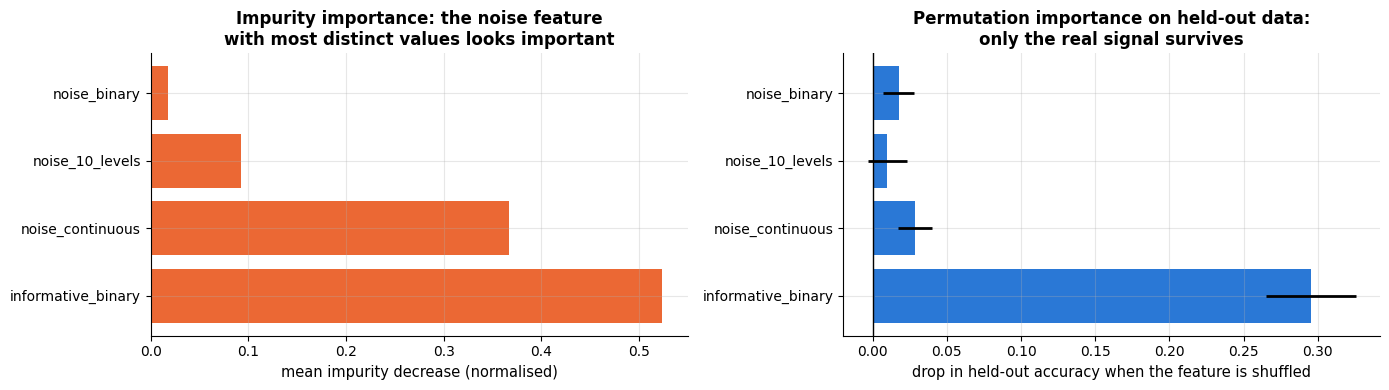

,impurity importance,permutation importance (held out)
informative_binary,0.523,0.295
noise_continuous,0.366,0.028
noise_10_levels,0.092,0.010
noise_binary,0.018,0.018


In [17]:
from sklearn.inspection import permutation_importance

n_imp = 900
X_imp = pd.DataFrame({
    "informative_binary": rng.integers(0, 2, n_imp).astype(float),
    "noise_continuous": rng.normal(size=n_imp),            # pure noise, ~900 distinct values
    "noise_10_levels": rng.integers(0, 10, n_imp).astype(float),   # pure noise, 10 values
    "noise_binary": rng.integers(0, 2, n_imp).astype(float),       # pure noise, 2 values
})
y_imp = ((X_imp["informative_binary"] * 2 + rng.normal(0, 1.0, n_imp)) > 1).astype(int)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imp, y_imp, test_size=0.35, stratify=y_imp,
                                              random_state=RANDOM_STATE)
frf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(Xi_tr, yi_tr)
perm = permutation_importance(frf, Xi_te, yi_te, n_repeats=15, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.0))
order = np.arange(len(X_imp.columns))
axes[0].barh(X_imp.columns[order], frf.feature_importances_[order], color=PALETTE[1])
axes[0].set_xlabel("mean impurity decrease (normalised)")
axes[0].set_title("Impurity importance: the noise feature\nwith most distinct values looks important")
axes[1].barh(X_imp.columns[order], perm.importances_mean[order],
             xerr=perm.importances_std[order], color=PALETTE[0])
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("drop in held-out accuracy when the feature is shuffled")
axes[1].set_title("Permutation importance on held-out data:\nonly the real signal survives")
plt.tight_layout()
plt.show()
pd.DataFrame({"impurity importance": frf.feature_importances_,
              "permutation importance (held out)": perm.importances_mean},
             index=X_imp.columns).round(3)

The continuous noise feature collects more than a third of the impurity-based importance even
though it carries no information at all, and the ranking of the three noise features follows
their number of distinct values exactly — 900, then 10, then 2. Permutation importance
computed **on held-out data** cuts it to a tenth of the real feature's score. (It does not
reach exactly zero, and it should not: the forest genuinely *did* fit some noise, so shuffling
that column genuinely does change its predictions. Permutation importance answers "how much
does this model rely on this feature?", which is the question you usually want.) Use
`permutation_importance` on a test or validation set whenever the answer matters; notebook 17
(interpretability) treats this properly, including what to do when features are correlated.

## 4. Boosting, part I: AdaBoost

### 4.1 The idea

Bagging perturbs the data randomly and hopes the members disagree. Boosting perturbs it
*deliberately*: it makes the next member concentrate on the examples the current ensemble
gets wrong.

> **History.** Kearns and Valiant asked in 1988 whether a "weak" learner — one that is only
> slightly better than chance — could always be boosted into a "strong" one. Schapire (1990)
> proved that it could, and Freund & Schapire's **AdaBoost** (1997) turned the proof into an
> algorithm so simple and so effective that it won them the 2003 Gödel Prize. Breiman called
> it "the best off-the-shelf classifier in the world".

### 4.2 The algorithm

We state the multi-class **SAMME** form (Zhu et al., 2009), which scikit-learn implements and
which reduces to the original AdaBoost when $K = 2$. Each training sample carries a weight
$w_i$; weights start uniform and are updated after every round.

> **Algorithm (AdaBoost / SAMME).** Initialise $w_i = 1/n$. For $m = 1, \dots, M$:
> 1. Fit a weak classifier $h_m$ to the training data **using the weights** $w$.
> 2. Compute its weighted error $\displaystyle \mathrm{err}_m = \sum_{i=1}^n w_i \,\mathbb{1}[y_i \ne h_m(\mathbf{x}_i)] \big/ \sum_i w_i$.
> 3. Compute its say in the final vote:
>    $\displaystyle \alpha_m = \log\frac{1 - \mathrm{err}_m}{\mathrm{err}_m} + \log(K-1)$.
> 4. Re-weight: $w_i \leftarrow w_i \exp\big(\alpha_m \mathbb{1}[y_i \ne h_m(\mathbf{x}_i)]\big)$, then renormalise.
>
> Predict $\displaystyle \hat y(\mathbf{x}) = \arg\max_k \sum_{m=1}^M \alpha_m \mathbb{1}[h_m(\mathbf{x}) = k]$.

Three things to notice. (i) A classifier with $\mathrm{err}_m$ just below chance
($1 - 1/K$) gets $\alpha_m \approx 0$ — no say. A perfect one gets $\alpha_m \to \infty$.
(ii) Only *misclassified* points have their weight multiplied by $e^{\alpha_m} > 1$, so hard
points get heavier and heavier. (iii) After the update, the just-fitted classifier has a
weighted error of exactly $1 - 1/K$ on the new weights: the next learner is forced to look
somewhere else.

The weak learner is traditionally a **decision stump** — a tree of depth 1, one split, the
weakest non-trivial model there is.

### 4.3 AdaBoost from scratch

In [18]:
def adaboost_fit(X, y, n_rounds=50, max_depth=1, random_state=0):
    """SAMME AdaBoost with decision trees of depth `max_depth` as weak learners."""
    n = len(y)
    classes = np.unique(y)
    K = len(classes)
    w = np.full(n, 1.0 / n)
    learners, alphas, weight_history = [], [], [w.copy()]
    for m in range(n_rounds):
        h = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
        h.fit(X, y, sample_weight=w)                       # <- the weights enter here
        miss = h.predict(X) != y
        err = np.clip(np.sum(w * miss), 1e-10, 1 - 1e-10)  # weights already sum to 1
        alpha = np.log((1 - err) / err) + np.log(K - 1)
        w = w * np.exp(alpha * miss)                       # only mistakes are up-weighted
        w /= w.sum()
        learners.append(h)
        alphas.append(alpha)
        weight_history.append(w.copy())
    return learners, np.array(alphas), np.array(weight_history), classes

def adaboost_predict(learners, alphas, classes, X, n_rounds=None):
    m = n_rounds if n_rounds is not None else len(learners)
    votes = np.zeros((len(X), len(classes)))
    for h, a in zip(learners[:m], alphas[:m]):
        pred = h.predict(X)
        for k, c in enumerate(classes):
            votes[:, k] += a * (pred == c)
    return classes[votes.argmax(axis=1)]

And the verification — this one is exact, because the update rule has no randomness in it:

In [19]:
from sklearn.ensemble import AdaBoostClassifier

learners, alphas, w_hist, classes = adaboost_fit(Xm_tr, ym_tr, n_rounds=50, random_state=RANDOM_STATE)
ours = accuracy_score(ym_te, adaboost_predict(learners, alphas, classes, Xm_te))

sk_ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                            n_estimators=50, random_state=RANDOM_STATE).fit(Xm_tr, ym_tr)
print(f"our AdaBoost test accuracy       {ours:.4f}")
print(f"sklearn AdaBoost test accuracy   {sk_ada.score(Xm_te, ym_te):.4f}")
print(f"our alphas[:5]      {np.round(alphas[:5], 5)}")
print(f"sklearn alphas[:5]  {np.round(sk_ada.estimator_weights_[:5], 5)}")
print(f"largest absolute difference between the 50 estimator weights: "
      f"{np.abs(alphas - sk_ada.estimator_weights_).max():.2e}")

our AdaBoost test accuracy       0.8667
sklearn AdaBoost test accuracy   0.8667
our alphas[:5]      [1.57554 0.96748 1.40003 0.78857 0.73966]
sklearn alphas[:5]  [1.57554 0.96748 1.40003 0.78857 0.73966]
largest absolute difference between the 50 estimator weights: 1.36e-15


The estimator weights agree to machine precision: our twelve-line loop *is* scikit-learn's
algorithm.

### 4.4 Watching the weights

The reweighting is the heart of AdaBoost, so let us draw it. Each panel shows the training
data with marker area proportional to the current sample weight, plus the split chosen by
that round's stump.

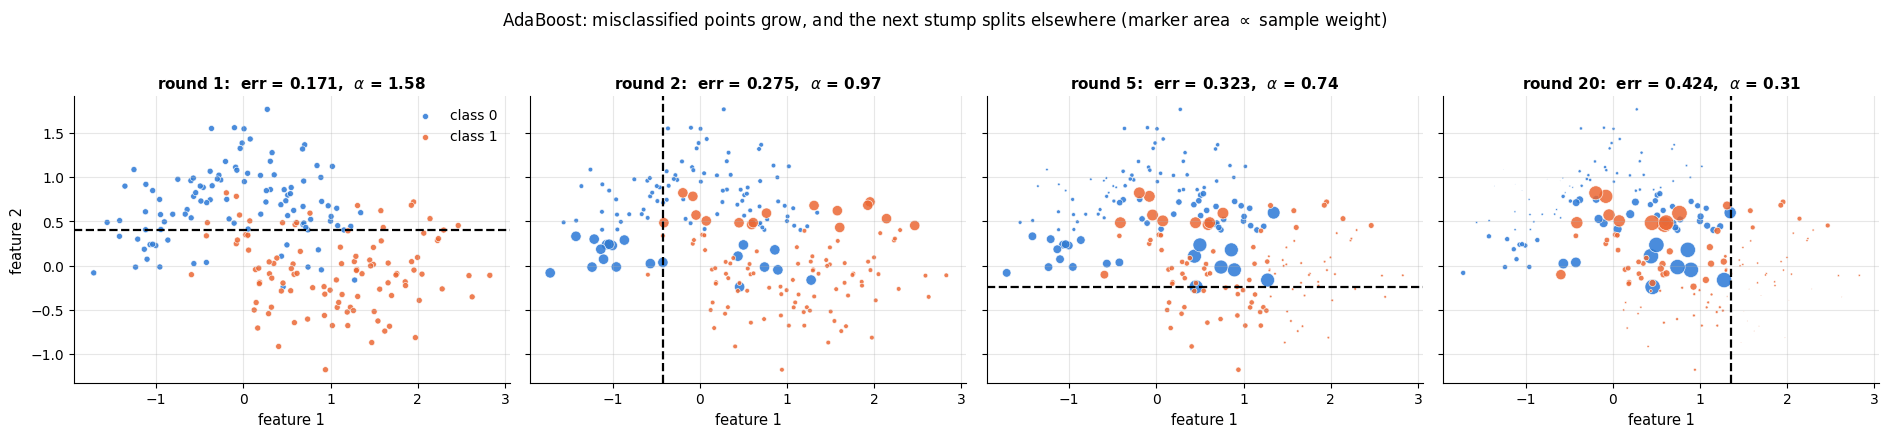

In [20]:
show_rounds = [1, 2, 5, 20]
fig, axes = plt.subplots(1, len(show_rounds), figsize=(19, 4.2), sharex=True, sharey=True)
for ax, m in zip(axes, show_rounds):
    w = w_hist[m - 1]                                  # weights the stump of round m was fitted with
    stump = learners[m - 1]
    for k, c in enumerate(classes):
        sel = ym_tr == c
        ax.scatter(Xm_tr[sel, 0], Xm_tr[sel, 1], s=4000 * w[sel], color=PALETTE[k],
                   edgecolor="white", linewidth=0.5, alpha=0.85, label=f"class {c}")
    # the stump splits on one feature at one threshold: draw it
    feat = stump.tree_.feature[0]
    thr = stump.tree_.threshold[0]
    (ax.axvline if feat == 0 else ax.axhline)(thr, color="black", lw=1.6, ls="--")
    ax.set_title(f"round {m}:  err = {np.sum(w * (stump.predict(Xm_tr) != ym_tr)):.3f},  "
                 f"$\\alpha$ = {alphas[m - 1]:.2f}", fontsize=11)
    ax.set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")
axes[0].legend(loc="upper right")
fig.suptitle("AdaBoost: misclassified points grow, and the next stump splits elsewhere "
             "(marker area $\\propto$ sample weight)", y=1.03)
plt.tight_layout()
plt.show()

Round 1 uses uniform weights; by round 20 the mass has concentrated on a few dozen points
near the boundary between the two moons. The growth is easier to quantify in a second
figure: the weight trajectory of every training point over the 50 rounds.

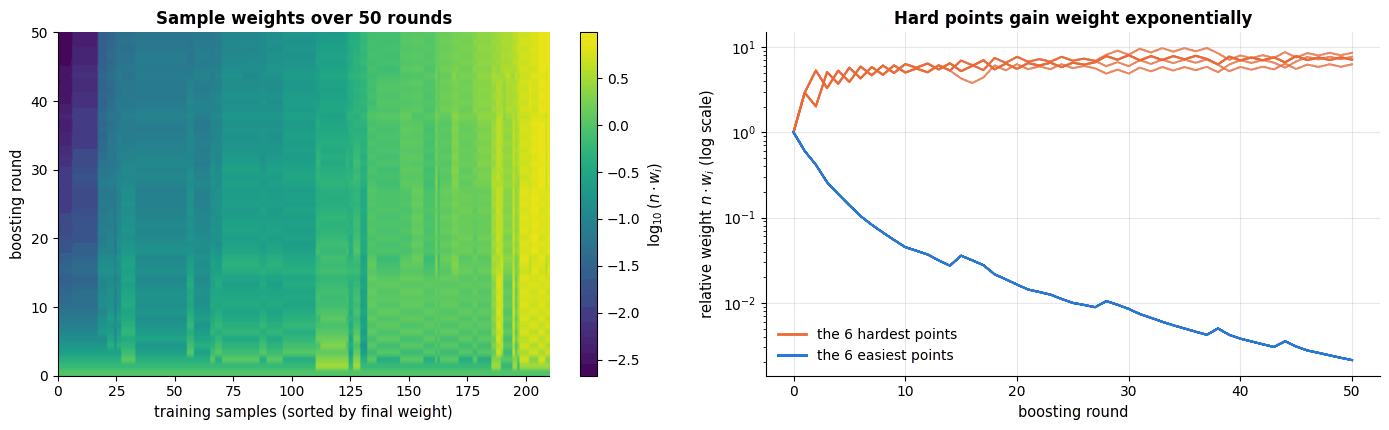

heaviest point carries 4.1% of the total weight after 50 rounds (uniform would be 0.48%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
final_order = np.argsort(w_hist[-1])
im = axes[0].imshow(np.log10(w_hist[:, final_order] * len(ym_tr) + 1e-12), aspect="auto",
                    origin="lower", cmap="viridis", extent=[0, len(ym_tr), 0, len(w_hist) - 1])
axes[0].set_xlabel("training samples (sorted by final weight)")
axes[0].set_ylabel("boosting round")
axes[0].set_title("Sample weights over 50 rounds")
axes[0].grid(False)
plt.colorbar(im, ax=axes[0], label=r"$\log_{10}(n \cdot w_i)$")

hardest = final_order[-6:]
easiest = final_order[:6]
for i in hardest:
    axes[1].plot(w_hist[:, i] * len(ym_tr), color=PALETTE[1], alpha=0.8, lw=1.5)
for i in easiest:
    axes[1].plot(w_hist[:, i] * len(ym_tr), color=PALETTE[0], alpha=0.8, lw=1.5)
axes[1].plot([], [], color=PALETTE[1], label="the 6 hardest points")
axes[1].plot([], [], color=PALETTE[0], label="the 6 easiest points")
axes[1].set_yscale("log")
axes[1].set_xlabel("boosting round")
axes[1].set_ylabel(r"relative weight $n \cdot w_i$ (log scale)")
axes[1].set_title("Hard points gain weight exponentially")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"heaviest point carries {w_hist[-1].max():.1%} of the total weight after 50 rounds "
      f"(uniform would be {1 / len(ym_tr):.2%})")

That exponential growth is AdaBoost's strength and its Achilles heel. A genuinely hard point
deserves attention; a **mislabelled** point does not, and AdaBoost cannot tell them apart.
We demonstrate the resulting failure in section 9.2.

### 4.5 The ensemble taking shape, and the margin surprise

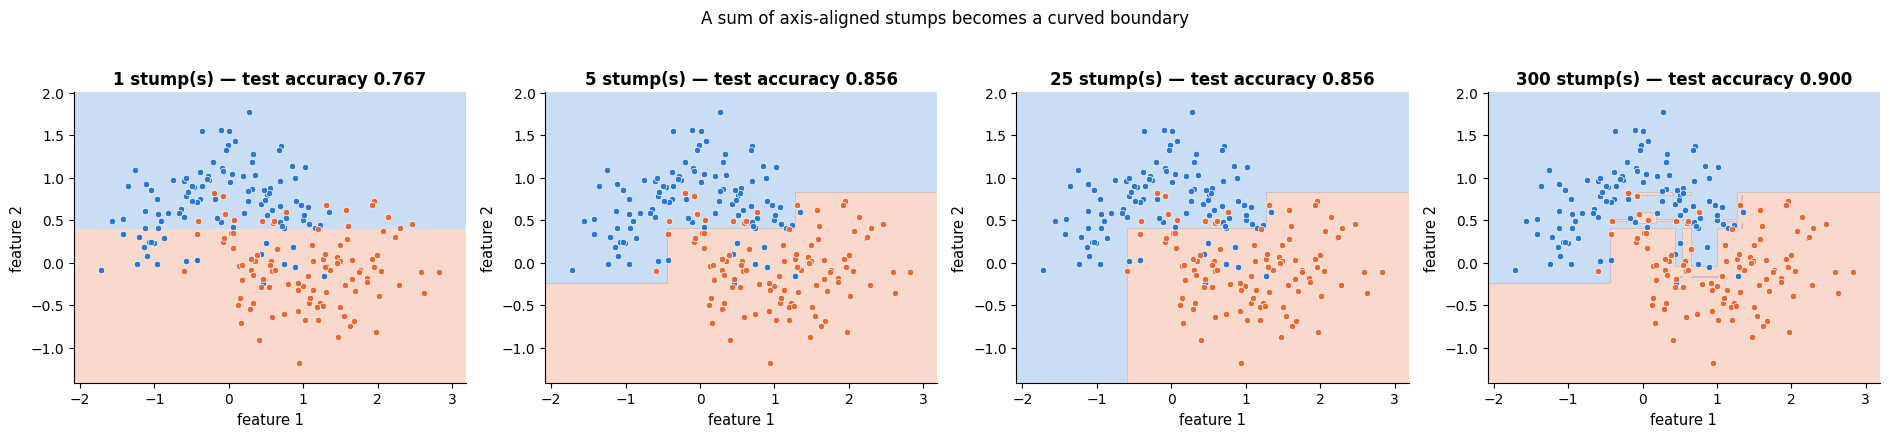

In [22]:
M_big = 300
big_learners, big_alphas, _, _ = adaboost_fit(Xm_tr, ym_tr, n_rounds=M_big, random_state=RANDOM_STATE)

class _Ada:                                   # a tiny adapter so plot_decision_boundary can call predict
    def __init__(self, m):
        self.m = m
    def predict(self, X):
        return adaboost_predict(big_learners, big_alphas, classes, X, n_rounds=self.m)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, m in zip(axes, [1, 5, 25, M_big]):
    model = _Ada(m)
    acc = accuracy_score(ym_te, model.predict(Xm_te))
    plot_decision_boundary(model, Xm_tr, ym_tr, ax=ax, title=f"{m} stump(s) — test accuracy {acc:.3f}")
    ax.legend().set_visible(False)
fig.suptitle("A sum of axis-aligned stumps becomes a curved boundary", y=1.03)
plt.tight_layout()
plt.show()

One stump is a vertical line. Three hundred stumps, weighted by their $\alpha_m$, trace the
crescent boundary of the moons. Now the classic AdaBoost curiosity: what happens when we keep
boosting long after the ensemble has stopped improving? We draw the error against the round,
evaluating on a large fresh sample (4 000 points from the same generator) so that the curve is
not dominated by the noise of a 90-point test set.

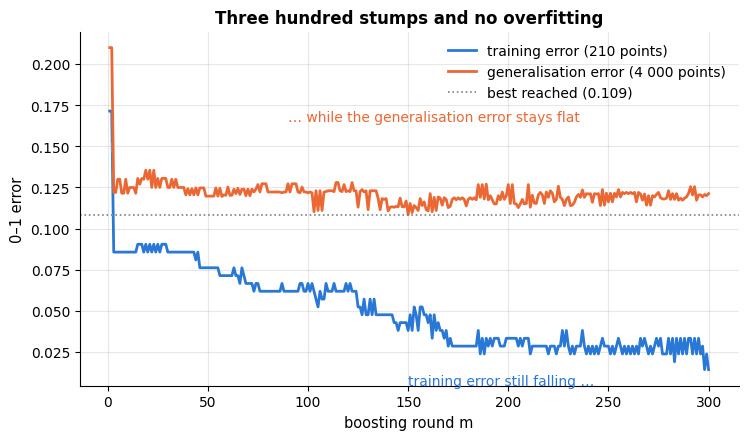

round    1:  training error 0.171   generalisation error 0.210
round    5:  training error 0.086   generalisation error 0.130
round   25:  training error 0.090   generalisation error 0.130
round  100:  training error 0.067   generalisation error 0.122
round  300:  training error 0.014   generalisation error 0.121


In [23]:
X_eval_moon, y_eval_moon = make_moons(n_samples=4000, noise=0.30, random_state=RANDOM_STATE + 1)

def staged_error(X, y):
    """Accumulate the weighted votes round by round instead of re-predicting from scratch."""
    votes = np.zeros((len(X), len(classes)))
    errs = []
    for h, a in zip(big_learners, big_alphas):
        pred = h.predict(X)
        for k, c in enumerate(classes):
            votes[:, k] += a * (pred == c)
        errs.append(1 - accuracy_score(y, classes[votes.argmax(axis=1)]))
    return np.array(errs)

train_err = staged_error(Xm_tr, ym_tr)
eval_err = staged_error(X_eval_moon, y_eval_moon)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(range(1, M_big + 1), train_err, color=PALETTE[0], label="training error (210 points)")
ax.plot(range(1, M_big + 1), eval_err, color=PALETTE[1], label="generalisation error (4 000 points)")
ax.axhline(eval_err.min(), color="gray", ls=":", lw=1.2, label=f"best reached ({eval_err.min():.3f})")
ax.annotate("training error still falling …", xy=(250, train_err[249]),
            xytext=(150, 0.005), color=PALETTE[0], fontsize=10)
ax.annotate("… while the generalisation error stays flat", xy=(250, eval_err[249]),
            xytext=(90, 0.165), color=PALETTE[1], fontsize=10)
ax.set_xlabel("boosting round m")
ax.set_ylabel("0–1 error")
ax.set_title("Three hundred stumps and no overfitting")
ax.legend(loc="upper right")
plt.show()
for m in [1, 5, 25, 100, M_big]:
    print(f"round {m:4d}:  training error {train_err[m - 1]:.3f}   generalisation error {eval_err[m - 1]:.3f}")

Look at what does *not* happen. From round 5 to round 300 the training error falls from 8.6 %
to 1.4 % — the ensemble is steadily absorbing the training set, including its noise — yet the
generalisation error does not rise at all; it drifts down from 13 % to 12 % and stays there.
Three hundred weighted stumps fitted to 210 training points is an enormous hypothesis space,
and classical complexity intuition says the gap should blow up.

> **Going deeper — margins.** Schapire et al. (1998) explained the missing overfitting with
> **margins**: even after the training *error* has almost stopped changing, extra rounds keep
> pushing the *confidence* $\sum_m \alpha_m \mathbb{1}[h_m = y] / \sum_m \alpha_m$ of the
> correct label upwards, and generalisation bounds stated in terms of the margin
> *distribution* — not the number of parameters — keep improving. It is the same intuition as
> the maximum-margin principle of support vector machines (notebook 11). The effect is real
> but it is not a guarantee: section 9.2 shows the same algorithm overfitting spectacularly
> once some of the labels are wrong.

### 4.6 AdaBoost is forward stagewise fitting of the exponential loss

The algorithm looks like a heuristic. It is not. Friedman, Hastie & Tibshirani (2000) showed
that, for $y \in \{-1, +1\}$ and $F(\mathbf{x}) = \sum_m \alpha_m h_m(\mathbf{x})$, AdaBoost
is exactly greedy stagewise minimisation of the **exponential loss**

$$
\mathcal{L}(F) \;=\; \sum_{i=1}^n \exp\big(-y_i F(\mathbf{x}_i)\big),
$$

where at each step $(\alpha_m, h_m)$ minimises the loss with the previous terms held fixed.
Writing $w_i^{(m)} = \exp(-y_i F_{m-1}(\mathbf{x}_i))$ gives precisely the weight update of
step 4. This reframing is what made **gradient boosting** possible: if AdaBoost is stagewise
descent on *one* loss, we can do stagewise descent on *any* loss.

It also explains the noise sensitivity. The exponential loss grows without bound as the
margin $y_i F(\mathbf{x}_i)$ becomes negative, so a mislabelled point is punished
exponentially. The logistic loss grows only linearly, which is why gradient boosting with
`loss="log_loss"` is the safer default.

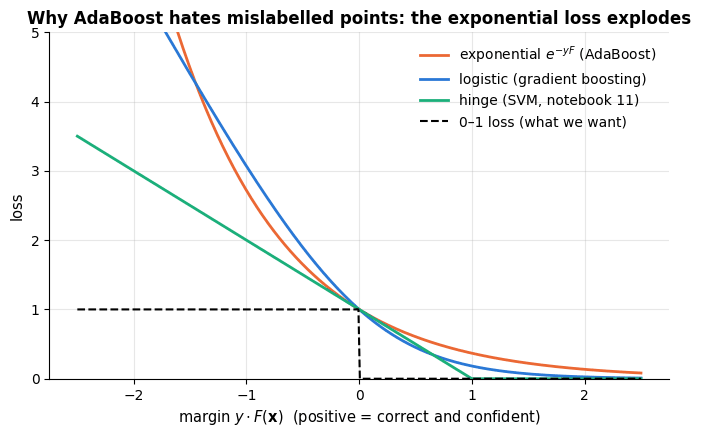

In [24]:
margin = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(margin, np.exp(-margin), color=PALETTE[1], label=r"exponential $e^{-yF}$ (AdaBoost)")
ax.plot(margin, np.log2(1 + np.exp(-2 * margin)), color=PALETTE[0], label=r"logistic (gradient boosting)")
ax.plot(margin, np.maximum(0, 1 - margin), color=PALETTE[2], label=r"hinge (SVM, notebook 11)")
ax.plot(margin, (margin <= 0).astype(float), color="black", lw=1.5, ls="--", label="0–1 loss (what we want)")
ax.set_ylim(0, 5)
ax.set_xlabel(r"margin $y \cdot F(\mathbf{x})$  (positive = correct and confident)")
ax.set_ylabel("loss")
ax.set_title("Why AdaBoost hates mislabelled points: the exponential loss explodes")
ax.legend()
plt.show()

## 5. Boosting, part II: gradient boosting

### 5.1 Boosting as gradient descent in function space

Here is Friedman's (2001) derivation, which is worth following symbol by symbol. We want to
minimise the empirical risk over functions,

$$
\mathcal{L}(F) \;=\; \sum_{i=1}^n \ell\big(y_i, F(\mathbf{x}_i)\big),
$$

but $F$ lives in an infinite-dimensional space, so we cannot simply take a derivative with
respect to "the parameters". Friedman's trick: treat the $n$ numbers
$\big(F(\mathbf{x}_1), \dots, F(\mathbf{x}_n)\big)$ as the parameters. Gradient descent on
those would say: move each $F(\mathbf{x}_i)$ in the direction of the negative gradient

$$
g_i \;=\; -\left[\frac{\partial \ell(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)}\right]_{F = F_{m-1}} ,
$$

which is called the **pseudo-residual** of sample $i$. But that only tells us how to change
the prediction at the $n$ training points, and we need a *function* defined everywhere. So we
fit a regression tree $h_m$ to the pairs $(\mathbf{x}_i, g_i)$ — the tree is the best
available approximation of the gradient direction inside our hypothesis space — and take a
shrunken step:

$$
F_m(\mathbf{x}) \;=\; F_{m-1}(\mathbf{x}) \;+\; \eta \, h_m(\mathbf{x}), \qquad 0 < \eta \le 1 .
$$

> **Algorithm (gradient boosting).**
> 1. $F_0(\mathbf{x}) = \arg\min_c \sum_i \ell(y_i, c)$ — the best constant.
> 2. For $m = 1, \dots, M$: compute pseudo-residuals $g_i$; fit a regression tree $h_m$ to
>    $(\mathbf{x}_i, g_i)$; optionally re-optimise each leaf value by a line search on $\ell$;
>    set $F_m = F_{m-1} + \eta\, h_m$.

For **squared loss** $\ell(y, F) = \tfrac12 (y - F)^2$ the pseudo-residual is
$g_i = y_i - F_{m-1}(\mathbf{x}_i)$ — the ordinary residual, and the line search is
unnecessary because a regression tree already predicts leaf means. *Gradient boosting for
regression is literally "fit a small tree to what is left over, add a fraction of it,
repeat."* For the **logistic loss** with $p = \sigma(F)$, the pseudo-residual is
$g_i = y_i - p_i$ — the probability error — which is why the same machinery classifies.

| loss | $\ell(y, F)$ | pseudo-residual $g_i$ | used for |
|---|---|---|---|
| squared error | $\tfrac12(y - F)^2$ | $y_i - F_i$ | regression (default) |
| absolute error | $\lvert y - F\rvert$ | $\operatorname{sign}(y_i - F_i)$ | robust regression |
| log loss (binary) | $\log(1 + e^{-2yF})$ | $y_i - \sigma(F_i)$ | classification (default) |
| Poisson | $e^{F} - y F$ | $y_i - e^{F_i}$ | counts |

### 5.2 Gradient boosting from scratch

In [25]:
def gb_fit(X, y, n_rounds=200, learning_rate=0.1, max_depth=3, random_state=0):
    """Gradient boosting for squared loss: fit shallow trees to the residuals."""
    F0 = y.mean()                                   # argmin_c sum (y_i - c)^2
    F = np.full(len(y), F0)
    trees, train_loss = [], [mean_squared_error(y, F)]
    for m in range(n_rounds):
        residual = y - F                            # pseudo-residual for squared loss
        h = DecisionTreeRegressor(max_depth=max_depth, criterion="friedman_mse",
                                  random_state=random_state).fit(X, residual)
        F = F + learning_rate * h.predict(X)        # a shrunken step in function space
        trees.append(h)
        train_loss.append(mean_squared_error(y, F))
    return F0, trees, np.array(train_loss)

def gb_predict(F0, trees, X, learning_rate=0.1, n_rounds=None):
    m = n_rounds if n_rounds is not None else len(trees)
    out = np.full(len(X), F0)
    for h in trees[:m]:
        out += learning_rate * h.predict(X)
    return out

In [26]:
F0, gb_trees, gb_train_loss = gb_fit(X_train, y_train, n_rounds=200, learning_rate=0.1,
                                     max_depth=3, random_state=RANDOM_STATE)
ours_pred = gb_predict(F0, gb_trees, X_test, 0.1)

sk_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                                  random_state=RANDOM_STATE).fit(X_train, y_train)
sk_pred = sk_gb.predict(X_test)
first_tree_match = np.abs(gb_trees[0].predict(X_test) - sk_gb.estimators_[0, 0].predict(X_test)).max()

print(f"our F0 = {F0:.4f};  sklearn's initial prediction = {sk_gb.init_.predict(X_test[:1])[0]:.4f}")
print(f"round-1 tree: largest prediction difference = {first_tree_match:.2e}  (identical)")
print(f"test MSE  ours {mean_squared_error(y_test, ours_pred):.4f}   "
      f"sklearn {mean_squared_error(y_test, sk_pred):.4f}")
print(f"prediction vectors: RMS difference {np.sqrt(np.mean((ours_pred - sk_pred)**2)):.4f} "
      f"= {np.sqrt(np.mean((ours_pred - sk_pred)**2)) / y_test.std():.2%} of the target's sd")

our F0 = 14.3975;  sklearn's initial prediction = 14.3975
round-1 tree: largest prediction difference = 0.00e+00  (identical)
test MSE  ours 2.6224   sklearn 2.6197
prediction vectors: RMS difference 0.0530 = 1.08% of the target's sd


The constant initialisation and the first tree are identical to scikit-learn's. Over 200
rounds the two implementations drift apart by a fraction of a percent of the target's
standard deviation: `DecisionTreeRegressor` breaks ties between equally good splits using its
`random_state`, and scikit-learn advances its random stream differently from our loop. The
algorithm is the same; the tie-breaking is not.

### 5.3 Watching the ensemble grow

The panel series every gradient-boosting explanation needs. We use a one-dimensional problem
so that the fitted function is visible, and show the ensemble after 1, 5, 20 and 100 rounds.

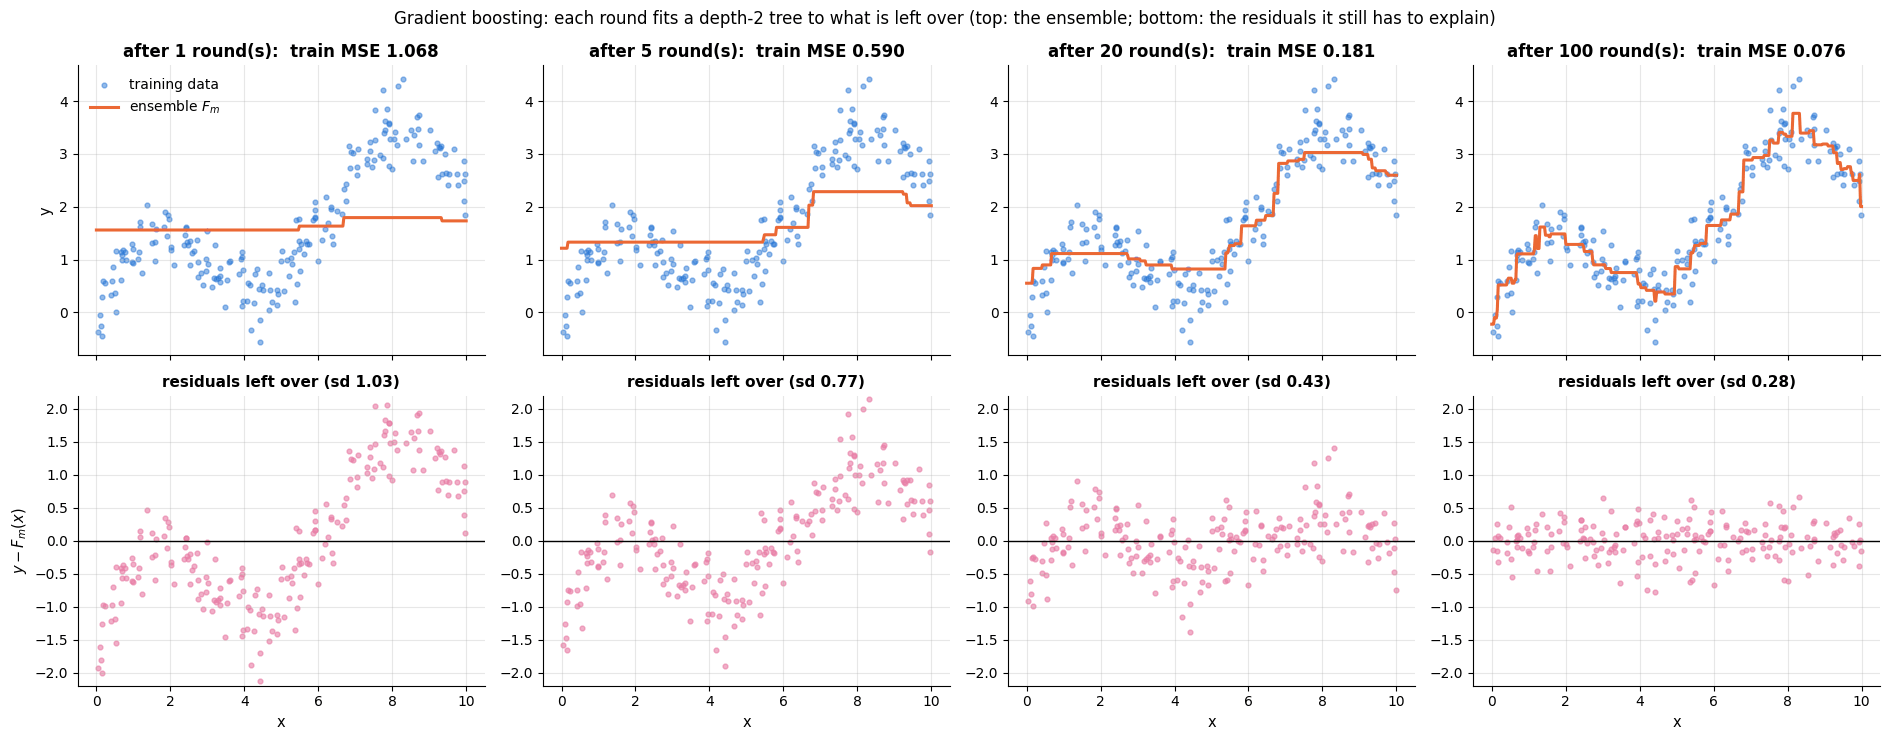

In [27]:
x1 = np.sort(rng.uniform(0, 10, 200))
y1 = np.sin(x1) + 0.30 * x1 + rng.normal(0, 0.35, len(x1))
grid = np.linspace(0, 10, 400)[:, None]
F0_1, trees_1, _ = gb_fit(x1[:, None], y1, n_rounds=100, learning_rate=0.1, max_depth=2,
                          random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 4, figsize=(19, 7.5), sharex=True)
for j, m in enumerate([1, 5, 20, 100]):
    fit_grid = gb_predict(F0_1, trees_1, grid, 0.1, n_rounds=m)
    fit_train = gb_predict(F0_1, trees_1, x1[:, None], 0.1, n_rounds=m)
    ax = axes[0, j]
    ax.scatter(x1, y1, s=12, color=PALETTE[0], alpha=0.5, label="training data")
    ax.plot(grid.ravel(), fit_grid, color=PALETTE[1], lw=2.2, label="ensemble $F_m$")
    ax.set_title(f"after {m} round(s):  train MSE {mean_squared_error(y1, fit_train):.3f}")
    ax = axes[1, j]
    ax.scatter(x1, y1 - fit_train, s=12, color=PALETTE[4], alpha=0.6)
    ax.axhline(0, color="black", lw=1)
    ax.set_ylim(-2.2, 2.2)
    ax.set_xlabel("x")
    ax.set_title(f"residuals left over (sd {np.std(y1 - fit_train):.2f})", fontsize=11)
axes[0, 0].set_ylabel("y")
axes[0, 0].legend(loc="upper left")
axes[1, 0].set_ylabel("$y - F_m(x)$")
fig.suptitle("Gradient boosting: each round fits a depth-2 tree to what is left over "
             "(top: the ensemble; bottom: the residuals it still has to explain)", y=0.98)
plt.tight_layout()
plt.show()

After one round the model is a constant plus one tiny step. After five it has the trend; after
twenty, the shape; after a hundred, the wiggles. The bottom row is the more instructive one:
the residual cloud starts structured (there is signal left) and ends unstructured (only noise
left). **When the residual plot looks like noise, stop.**

### 5.4 Shrinkage: the learning rate

The step size $\eta$ (`learning_rate`, also called *shrinkage*) is gradient boosting's most
important hyper-parameter after the number of rounds, and the two are locked together: halving
$\eta$ roughly doubles the number of rounds you need. Friedman (2001) found that small $\eta$
with many rounds generalises better than large $\eta$ with few — the ensemble explores the
function space in smaller, less greedy steps.

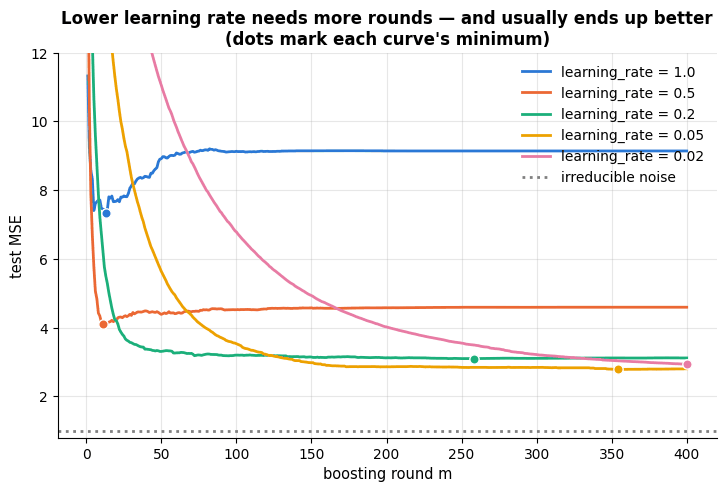

,best round,best test MSE,test MSE at 400
learning_rate,,,
1.00,13,7.334,9.142
0.50,11,4.095,4.596
0.20,258,3.100,3.121
0.05,354,2.786,2.805
0.02,400,2.940,2.940


In [28]:
X_g, y_g = make_friedman(700)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(X_g, y_g, test_size=0.35, random_state=RANDOM_STATE)
n_max = 400
fig, ax = plt.subplots(figsize=(8.5, 5))
summary = []
for i, eta in enumerate([1.0, 0.5, 0.2, 0.05, 0.02]):
    model = GradientBoostingRegressor(n_estimators=n_max, learning_rate=eta, max_depth=3,
                                      random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
    curve = np.array([mean_squared_error(yg_te, p) for p in model.staged_predict(Xg_te)])
    ax.plot(np.arange(1, n_max + 1), curve, color=PALETTE[i], label=f"learning_rate = {eta}")
    best = int(curve.argmin())
    ax.scatter([best + 1], [curve[best]], color=PALETTE[i], zorder=5, s=45, edgecolor="white")
    summary.append({"learning_rate": eta, "best round": best + 1, "best test MSE": curve[best],
                    "test MSE at 400": curve[-1]})
ax.axhline(1.0, color="gray", ls=":", label="irreducible noise")
ax.set_ylim(0.8, 12)
ax.set_xlabel("boosting round m")
ax.set_ylabel("test MSE")
ax.set_title("Lower learning rate needs more rounds — and usually ends up better\n"
             "(dots mark each curve's minimum)")
ax.legend()
plt.show()
pd.DataFrame(summary).set_index("learning_rate").round(3)

Two lessons are visible. With $\eta = 1.0$ the curve drops fast and then *rises* — classic
overfitting, because each greedy step is taken in full. With $\eta = 0.02$ the curve is still
falling at round 400: we simply have not boosted long enough. The best final error belongs to
one of the middle values. In practice: **fix $\eta$ small (0.05–0.1), then choose $M$ by early
stopping.**

### 5.5 Stochastic gradient boosting: `subsample`

Friedman (2002) added one line to the algorithm: fit each tree on a random fraction
(`subsample`, typically 0.5–0.8) of the training rows, drawn *without* replacement. This
injects bagging-style variance reduction into boosting, decorrelating consecutive trees, and
it makes each round cheaper.

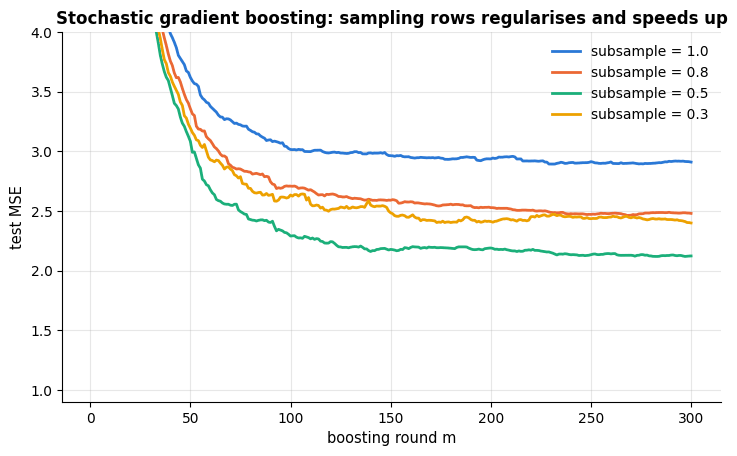

,best test MSE,at round
subsample,,
1.0,2.893,230
0.8,2.463,268
0.5,2.118,283
0.3,2.399,300


In [29]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
rows = []
for i, sub in enumerate([1.0, 0.8, 0.5, 0.3]):
    model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=3,
                                      subsample=sub, random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
    curve = np.array([mean_squared_error(yg_te, p) for p in model.staged_predict(Xg_te)])
    ax.plot(np.arange(1, 301), curve, color=PALETTE[i], label=f"subsample = {sub}")
    rows.append({"subsample": sub, "best test MSE": curve.min(), "at round": int(curve.argmin()) + 1})
ax.set_ylim(0.9, 4)
ax.set_xlabel("boosting round m")
ax.set_ylabel("test MSE")
ax.set_title("Stochastic gradient boosting: sampling rows regularises and speeds up")
ax.legend()
plt.show()
pd.DataFrame(rows).set_index("subsample").round(3)

Sampling half the rows per tree gives a clearly better model than using all of them, and each
round costs half as much. The mechanism is the one from section 1: consecutive trees see
different data, so they are less correlated, so their sum has lower variance. Below about 0.3
the trees become too noisy and the benefit reverses. **Try `subsample=0.5`–`0.8` whenever you
have more than a few hundred rows**; it is close to free.

### 5.6 Histogram gradient boosting: the modern implementation

`GradientBoostingRegressor` is the textbook implementation and it is **slow**: every split
search sorts the feature values of every node. The modern approach, introduced by LightGBM
(Ke et al., 2017) and adopted by scikit-learn as `HistGradientBoosting*`, **bins each feature
into at most 255 integer buckets once**, before boosting starts. Split search then becomes a
pass over a histogram of 255 bins instead of a sort of $n$ values — the cost per split drops
from $O(n\log n)$ to $O(n + \text{bins})$, and the binned data fits in cache. Accuracy loss
from binning is usually negligible, because a tree only needs to find an approximately right
threshold.

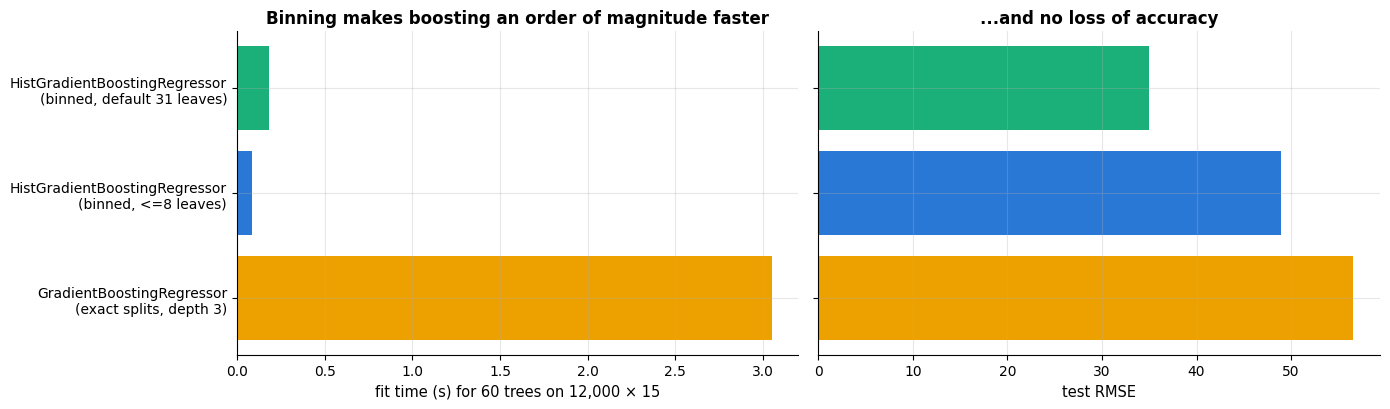

speed-up at equal tree size: 34x


,fit time (s),test RMSE
implementation,,
"GradientBoostingRegressor\n(exact splits, depth 3)",3.049,56.574
"HistGradientBoostingRegressor\n(binned, <=8 leaves)",0.089,48.939
"HistGradientBoostingRegressor\n(binned, default 31 leaves)",0.183,34.930


In [30]:
from sklearn.datasets import make_regression
from sklearn.ensemble import HistGradientBoostingRegressor

N_ROUNDS = 60          # kept small so that the slow implementation still fits the runtime budget
X_big, y_big = make_regression(n_samples=16000, n_features=15, n_informative=10, noise=10.0,
                               random_state=RANDOM_STATE)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_big, y_big, test_size=0.25, random_state=RANDOM_STATE)

timing = []
for name, model in [
    ("GradientBoostingRegressor\n(exact splits, depth 3)",
     GradientBoostingRegressor(n_estimators=N_ROUNDS, max_depth=3, learning_rate=0.1,
                               random_state=RANDOM_STATE)),
    ("HistGradientBoostingRegressor\n(binned, <=8 leaves)",
     HistGradientBoostingRegressor(max_iter=N_ROUNDS, max_leaf_nodes=8, learning_rate=0.1,
                                   early_stopping=False, random_state=RANDOM_STATE)),
    ("HistGradientBoostingRegressor\n(binned, default 31 leaves)",
     HistGradientBoostingRegressor(max_iter=N_ROUNDS, learning_rate=0.1, early_stopping=False,
                                   random_state=RANDOM_STATE)),
]:
    t0 = time.perf_counter()
    model.fit(Xb_tr, yb_tr)
    timing.append({"implementation": name, "fit time (s)": time.perf_counter() - t0,
                   "test RMSE": mean_squared_error(yb_te, model.predict(Xb_te)) ** 0.5})
tdf = pd.DataFrame(timing).set_index("implementation")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].barh(tdf.index, tdf["fit time (s)"], color=[PALETTE[3], PALETTE[0], PALETTE[2]])
axes[0].set_xlabel(f"fit time (s) for {N_ROUNDS} trees on {Xb_tr.shape[0]:,} × {Xb_tr.shape[1]}")
axes[0].set_title("Binning makes boosting an order of magnitude faster")
axes[1].barh(tdf.index, tdf["test RMSE"], color=[PALETTE[3], PALETTE[0], PALETTE[2]])
axes[1].set_xlabel("test RMSE")
axes[1].set_title("...and no loss of accuracy")
axes[1].tick_params(labelleft=False)
plt.tight_layout()
plt.show()
print(f"speed-up at equal tree size: {tdf['fit time (s)'].iloc[0] / tdf['fit time (s)'].iloc[1]:.0f}x")
tdf.round(3)

Same number of trees, same depth, one to two orders of magnitude less time — and the binned
model is *more* accurate, not less, because at that price you can afford its default 31-leaf
trees instead of 8-leaf ones. (Timings in this notebook are measured inside a small shared
container; read them as ratios, not as benchmarks for your laptop.)

`HistGradientBoosting*` also brings two features that remove whole preprocessing steps:

- **Native missing-value support.** NaNs are sent to whichever child reduces the loss most,
  learned per split. No imputation needed.
- **Native categorical support.** With `categorical_features="from_dtype"` a pandas
  `category` column is split by partitioning its levels directly, instead of being one-hot
  expanded into many nearly-useless binary columns.

In [31]:
cities = rng.choice(["Lisbon", "Oslo", "Cairo", "Lima", "Osaka"], 600)
demo = pd.DataFrame({"amount": rng.lognormal(3, 0.6, 600),
                     "city": pd.Categorical(cities)})
demo.loc[rng.random(len(demo)) < 0.15, "amount"] = np.nan          # 15 % missing, on purpose
effect = np.array([{"Lisbon": 3.0, "Oslo": -2.0, "Cairo": 0.5, "Lima": 0.0, "Osaka": 2.5}[c]
                   for c in cities])
y_demo = np.log(demo["amount"].to_numpy(dtype=float, na_value=20.0)) + effect + rng.normal(0, 0.5, 600)

hgb_native = HistGradientBoostingRegressor(categorical_features="from_dtype", max_iter=80,
                                           random_state=RANDOM_STATE).fit(demo, y_demo)
cat_cols = [c for c, flag in zip(demo.columns, hgb_native.is_categorical_) if flag]
print(f"fitted directly on a frame with NaNs and a category column: "
      f"R^2 = {hgb_native.score(demo, y_demo):.3f}")
print(f"columns treated as categorical: {cat_cols}")
print(f"missing values in the frame: {int(demo['amount'].isna().sum())} — no imputer in sight")

fitted directly on a frame with NaNs and a category column: R^2 = 0.953
columns treated as categorical: ['city']
missing values in the frame: 103 — no imputer in sight


### 5.7 XGBoost, LightGBM, CatBoost

Three libraries dominate competition leaderboards. They are optional here — the notebook is
complete without them — but you should know what each adds.

In [32]:
optional = {}
for lib in ["xgboost", "lightgbm", "catboost"]:
    try:
        __import__(lib)
        optional[lib] = True
    except ImportError:
        optional[lib] = False
missing = [k for k, v in optional.items() if not v]
if missing:
    print(f"not installed here: {', '.join(missing)} — the comparison below is descriptive only.")
    print("Install with: conda install -c conda-forge xgboost lightgbm catboost")
else:
    print("all three boosting libraries are available")

not installed here: xgboost, lightgbm, catboost — the comparison below is descriptive only.
Install with: conda install -c conda-forge xgboost lightgbm catboost


| Library | Key contribution | When it matters |
|---|---|---|
| **XGBoost** (Chen & Guestrin, 2016) | explicit regularised objective (an $L_2$ penalty $\lambda$ and a per-leaf cost $\gamma$ inside the split gain), **second-order** (Newton) steps using both gradient and Hessian, sparsity-aware split finding, out-of-core training | the most battle-tested; strong when you want fine control of regularisation |
| **LightGBM** (Ke et al., 2017) | histogram binning (now also in scikit-learn), **leaf-wise** growth (always split the leaf with the largest loss reduction, instead of level-wise), GOSS sampling and exclusive feature bundling | fastest on wide, large data; `num_leaves` replaces `max_depth` as the capacity knob |
| **CatBoost** (Prokhorenkova et al., 2018) | **ordered boosting** and ordered target statistics, which remove the target leakage of naive target encoding; symmetric (oblivious) trees; excellent categorical handling out of the box | data with many high-cardinality categorical columns |

For everything in this course, scikit-learn's `HistGradientBoosting*` is close enough to
these in both speed and accuracy that we use it as the reference boosting model. Reach for the
others when you need their specific features, or when a competition's last 0.1 % matters.

## 6. Stacking and voting

Bagging and boosting combine copies of *one* model. **Voting** and **stacking** combine
*different* models — and they help exactly when the models make different mistakes.

- **Voting** (`VotingClassifier`, `VotingRegressor`). Fixed combination: majority vote
  (`voting="hard"`), average of predicted probabilities (`voting="soft"`, usually better), or
  a weighted average. No extra parameters to fit.
- **Stacking** (Wolpert, 1992; `StackingClassifier`). *Learn* the combination. Each base model
  produces out-of-fold predictions on the training data via internal cross-validation; those
  predictions become the features of a **meta-learner** (a regularised linear model is the
  standard, and usually the best, choice). The cross-fitting is essential — training the
  meta-learner on in-sample predictions would let an overfitted base model claim all the
  weight.

In [33]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import StackingClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer(as_frame=True)
Xk, yk = cancer.data, cancer.target
Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(Xk, yk, test_size=0.3, stratify=yk,
                                              random_state=RANDOM_STATE)
base = [
    ("logreg", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11))),
    ("forest", RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE)),
    ("boosting", HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE)),
]
errors = {}
for name, model in base:
    model.fit(Xk_tr, yk_tr)
    errors[name] = (model.predict(Xk_te) != yk_te).astype(int)
err_df = pd.DataFrame(errors)
print("misclassified test samples per model: "
      + ", ".join(f"{k} {int(v)}" for k, v in err_df.sum().items()) + f"  (of {len(yk_te)})")
print(f"samples that at least one model gets wrong: {int((err_df.sum(axis=1) > 0).sum())}")
print(f"samples that ALL four get wrong:            {int((err_df.sum(axis=1) == 4).sum())}")
err_df.corr().round(2)

misclassified test samples per model: logreg 2, knn 6, forest 10, boosting 7  (of 171)
samples that at least one model gets wrong: 14
samples that ALL four get wrong:            1


,logreg,knn,forest,boosting
logreg,1.00,0.27,0.20,0.25
knn,0.27,1.00,0.49,0.44
forest,0.20,0.49,1.00,0.70
boosting,0.25,0.44,0.70,1.00


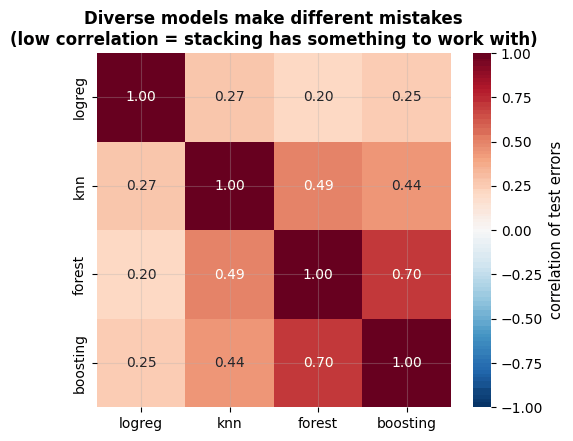

In [34]:
fig, ax = plt.subplots(figsize=(5.8, 4.6))
sns.heatmap(err_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"label": "correlation of test errors"})
ax.set_title("Diverse models make different mistakes\n(low correlation = stacking has something to work with)")
plt.show()

If every model failed on the same samples the correlation matrix would be all ones and no
combination could help. It is not, so let us combine.

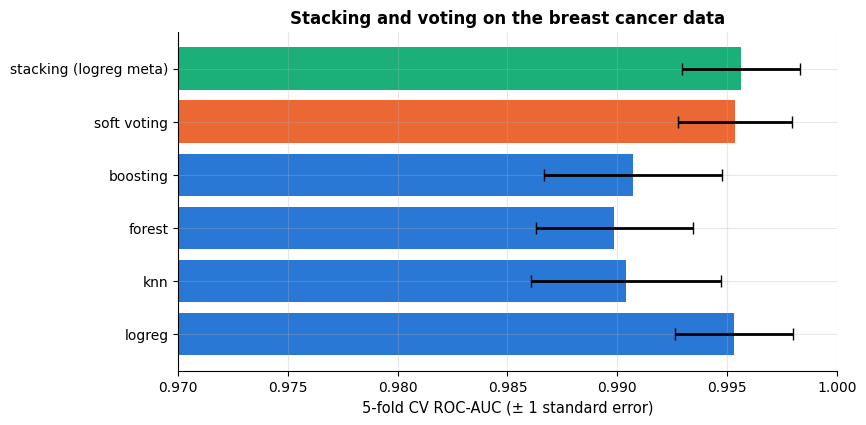

,CV ROC-AUC,SE
model,,
logreg,0.9953,0.0027
knn,0.9904,0.0043
forest,0.9899,0.0036
boosting,0.9907,0.0040
soft voting,0.9954,0.0026
stacking (logreg meta),0.9956,0.0027


In [35]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
vote = VotingClassifier(base, voting="soft")
stack = StackingClassifier(base, final_estimator=LogisticRegression(max_iter=5000), cv=3)

rows = []
for name, model in base + [("soft voting", vote), ("stacking (logreg meta)", stack)]:
    s = cross_val_score(model, Xk, yk, cv=cv5, scoring="roc_auc")
    rows.append({"model": name, "CV ROC-AUC": s.mean(), "SE": s.std(ddof=1) / np.sqrt(5)})
comb = pd.DataFrame(rows).set_index("model")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
colors = [PALETTE[0]] * 4 + [PALETTE[1], PALETTE[2]]
ax.barh(comb.index, comb["CV ROC-AUC"], xerr=comb["SE"], color=colors, capsize=4)
ax.set_xlim(0.97, 1.0)
ax.set_xlabel("5-fold CV ROC-AUC (± 1 standard error)")
ax.set_title("Stacking and voting on the breast cancer data")
plt.show()
comb.round(4)

> **Warning.** Stacking costs roughly (number of base models) × (inner folds + 1) fits, and on
> most problems it buys a fraction of a percent. Use it when that fraction matters (a
> competition, a high-stakes score) and when your base models are genuinely diverse; otherwise
> a well-tuned single boosting model is the better engineering trade-off. Note also that here
> the *simplest* base model is already at the top of the range — see section 11.

## 7. When do tree ensembles actually win?

Boosting is the default for tabular data, but "default" is not "always". The honest version of
the claim is about the **structure of the target function**, not about tables as such. We test
it with two data-generating processes of the same size and the same noise level: one smooth
and additive (made for a linear model), one built from interactions and thresholds (made for
trees).

In [36]:
def dgp_linear(n, rng):
    X = rng.uniform(-2, 2, size=(n, 8))
    y = 1.5 * X[:, 0] - 1.0 * X[:, 1] + 0.8 * X[:, 2] + 0.5 * X[:, 3] + rng.normal(0, 1.0, n)
    return X, y

def dgp_interactions(n, rng):
    X = rng.uniform(-2, 2, size=(n, 8))
    y = (3 * np.sign(X[:, 0] * X[:, 1]) + 2 * (X[:, 2] > 0.5) * X[:, 3]
         + 1.5 * np.abs(X[:, 4]) + rng.normal(0, 1.0, n))
    return X, y

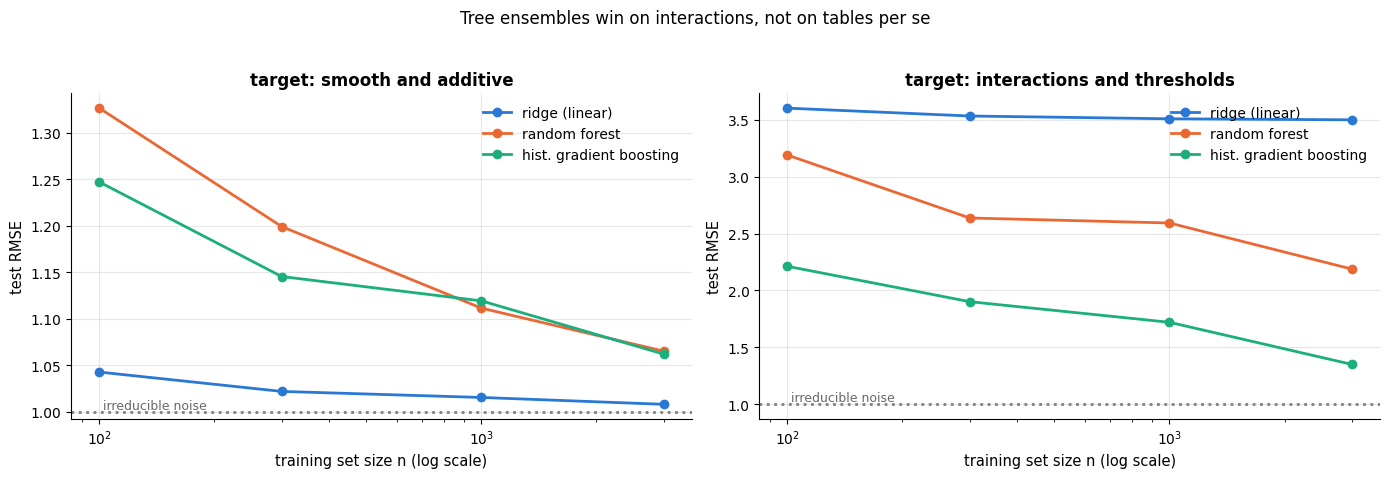

In [37]:
from sklearn.linear_model import RidgeCV

n_grid3 = [100, 300, 1000, 3000]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=False)
for ax, (title, dgp) in zip(axes, [("smooth and additive", dgp_linear),
                                   ("interactions and thresholds", dgp_interactions)]):
    X_pool, y_pool = dgp(max(n_grid3), rng)
    X_ev, y_ev = dgp(3000, rng)
    curves = {"ridge (linear)": [], "random forest": [], "hist. gradient boosting": []}
    for n in n_grid3:
        Xs, ys = X_pool[:n], y_pool[:n]
        fits = {
            "ridge (linear)": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 20))),
            "random forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
            "hist. gradient boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        }
        for k, model in fits.items():
            model.fit(Xs, ys)
            curves[k].append(mean_squared_error(y_ev, model.predict(X_ev)) ** 0.5)
    for i, (k, v) in enumerate(curves.items()):
        ax.plot(n_grid3, v, marker="o", color=PALETTE[i], label=k)
    ax.axhline(1.0, color="gray", ls=":")
    ax.text(n_grid3[0], 1.0, " irreducible noise", va="bottom", fontsize=9, color="dimgray")
    ax.set_xscale("log")
    ax.set_xlabel("training set size n (log scale)")
    ax.set_ylabel("test RMSE")
    ax.set_title(f"target: {title}")
    ax.legend(loc="upper right")
fig.suptitle("Tree ensembles win on interactions, not on tables per se", y=1.03)
plt.tight_layout()
plt.show()

On the smooth additive target the linear model is unbeatable at every sample size: it has the
right inductive bias and nothing to learn but four coefficients. Note, though, how the gap
closes — by $n = 3000$ the ensembles are within 6 % of the noise floor, so the cost of the
wrong inductive bias is small once you have enough data. On the interaction target the ordering
flips and the gap *widens* with $n$: boosting ends up at an RMSE of about 1.4 where the linear
model is stuck at 3.5, because ridge is not slowly converging to the truth — it is converging
to the best *linear* approximation of a function that is not linear, and that ceiling does not
move however much data you collect.

> **Why trees still beat deep learning on tabular data.** Grinsztajn, Oyallon & Varoquaux
> (2022) benchmarked tree ensembles against neural networks on 45 tabular datasets and found
> the trees ahead, even after careful tuning of the networks. Their diagnosis has three parts:
> (i) neural networks are biased towards *smooth* functions, while tabular targets are often
> irregular — exactly the piecewise-constant structure trees represent natively; (ii) neural
> networks are hurt by uninformative features, which trees simply never split on; (iii) trees
> are invariant to monotone transformations of each feature, so the arbitrary scales and heavy
> tails of real tables cost them nothing. Neural networks for tabular data are the natural
> continuation of this topic, and they belong to a dedicated deep-learning course; for the
> spreadsheet on your disk, start with `HistGradientBoosting*`.

## 8. Strengths, weaknesses and when to use them

The two families deserve separate verdicts.

### 8.1 Random forests (and extra trees)

| | |
|---|---|
| **Assumptions / inductive bias** | the target is well approximated by an average of axis-aligned piecewise-constant functions; no assumption about distributions, scales or linearity |
| **Strengths** | works out of the box with almost no tuning; no feature scaling; handles mixed feature types and non-linear interactions; robust to outliers in $\mathbf{x}$ and to label noise; free OOB error estimate; embarrassingly parallel; rarely overfits as $B$ grows |
| **Weaknesses / failure modes** | cannot extrapolate beyond the range of the training targets (section 9.1); large memory footprint (hundreds of deep trees); predictions are piecewise constant, so smooth trends are approximated by staircases; impurity importance is biased (section 3.4); slow at prediction time relative to a linear model; needs many trees to be smooth |
| **Data it suits** | $n$ from a few hundred to a few million; $d$ up to thousands; numeric + (encoded) categorical; moderate-to-high noise; missing values need imputation (scikit-learn's forest does not accept NaN) |
| **Complexity** | training $O(B \cdot m \cdot n\log^2 n)$ with $m$ = `max_features`; prediction $O(B\log n)$; memory $O(B \cdot \text{nodes})$ |
| **Interpretability** | feature importances (with the caveat above), partial dependence, proximities; individual trees are readable but the forest is not |
| **Use it when** | you want a strong, reliable baseline in one line, with minimal tuning and a free error estimate |
| **Avoid it when** | you must extrapolate, you need a compact/fast model, or the signal is genuinely linear and smooth |

### 8.2 Gradient boosting (including `HistGradientBoosting*`)

| | |
|---|---|
| **Assumptions / inductive bias** | the target is an additive sum of many small piecewise-constant corrections; the loss is differentiable in the prediction |
| **Strengths** | usually the best accuracy available on tabular data; any differentiable loss (squared, absolute, quantile, Poisson, log-loss); native missing-value and categorical handling in the histogram version; built-in early stopping; strong with heterogeneous, unscaled features; compact models (shallow trees) |
| **Weaknesses / failure modes** | **will** overfit if `n_estimators` is too large for the learning rate — the number of rounds must be validated; sensitive to label noise, much more than a forest (section 9.2); cannot extrapolate (section 9.1); sequential, so less parallel than a forest; more hyper-parameters, and they interact |
| **Data it suits** | tabular data of any size from ~100 rows upward; numeric + categorical; the histogram version scales to millions of rows |
| **Complexity** | training $O(M \cdot d \cdot n)$ for the histogram version after an $O(nd\log n)$ binning pass (versus $O(M \cdot d \cdot n\log n)$ for the exact version); prediction $O(M \cdot \text{depth})$ |
| **Interpretability** | same tools as a forest, plus partial dependence (introduced in Friedman, 2001) and SHAP values (notebook 17) |
| **Use it when** | accuracy on a table is what you are paid for, and you can afford to tune two or three parameters |
| **Avoid it when** | labels are unreliable, you have very few rows and a smooth signal, or you need to extrapolate |

**The verdict in one paragraph.** Start with a random forest: it is one line, it is almost
impossible to misuse, and the number it gives you is an honest floor for what the data
support. Then try `HistGradientBoosting*` with early stopping; on most real tables it will
beat the forest by a little, and on tables with strong interactions and enough rows it will
beat it by a lot. Keep the forest as the sanity check — when the tuned boosting model is
*worse* than an untuned forest, something is wrong with your validation, your labels, or
your data volume. And do not skip the linear baseline: section 11 is a reminder that on small,
smooth, low-dimensional problems it is still the model to beat.

## 9. The weaknesses, demonstrated

The two tables above assert a lot. The next two experiments *show* the two failure modes that
matter most in practice — one shared by both families, one that separates them.

### 9.1 Neither family can extrapolate

A tree predicts the mean of the training targets in a leaf. Outside the range of the training
inputs, *every* input falls into the outermost leaf, so the prediction is a constant. No
amount of boosting or averaging changes that — the ensemble is still a sum of piecewise
constant functions, and a piecewise constant function is flat at infinity.

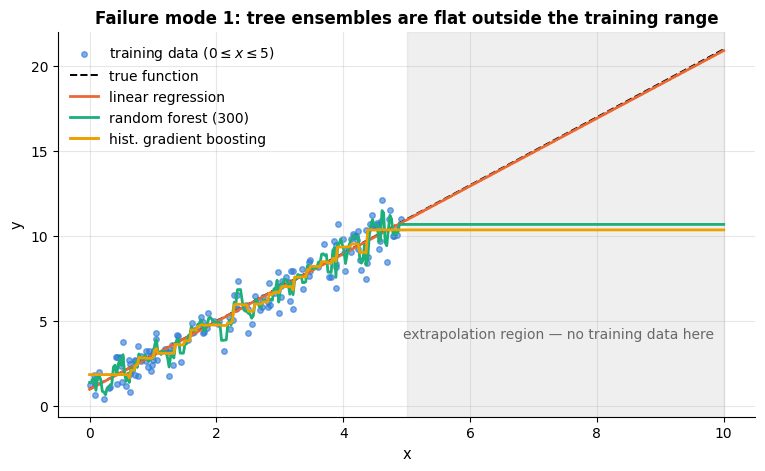

prediction at x = 9 (true value 19.0): linear regression           18.93
prediction at x = 9 (true value 19.0): random forest (300)         10.69
prediction at x = 9 (true value 19.0): hist. gradient boosting     10.37


In [38]:
x_lin = rng.uniform(0, 5, 160)
y_lin = 2.0 * x_lin + 1.0 + rng.normal(0, 0.8, len(x_lin))
x_all = np.linspace(0, 10, 400)[:, None]

from sklearn.linear_model import LinearRegression
fits = {
    "linear regression": LinearRegression(),
    "random forest (300)": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "hist. gradient boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_lin, y_lin, s=16, color=PALETTE[0], alpha=0.6, label="training data ($0 \\leq x \\leq 5$)")
ax.plot(x_all.ravel(), 2 * x_all.ravel() + 1, color="black", lw=1.4, ls="--", label="true function")
for i, (name, model) in enumerate(fits.items(), start=1):
    model.fit(x_lin[:, None], y_lin)
    ax.plot(x_all.ravel(), model.predict(x_all), color=PALETTE[i], lw=2, label=name)
ax.axvspan(5, 10, color="gray", alpha=0.12)
ax.annotate("extrapolation region — no training data here", xy=(7.4, 4),
            ha="center", fontsize=10, color="dimgray")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Failure mode 1: tree ensembles are flat outside the training range")
ax.legend(loc="upper left")
plt.show()
for name, model in fits.items():
    print(f"prediction at x = 9 (true value 19.0): {name:26s} {model.predict([[9.0]])[0]:6.2f}")

The forest and the boosting model flatten out at the mean of their right-most leaf, just above
10, while the truth at $x = 9$ is 19. **Consequences for practice:** never use a tree ensemble for a time series with a
trend without differencing or detrending it first (notebook 16 shows how); be careful with
features that drift over time (prices, counts, indices); and consider a hybrid — a linear
model for the trend plus a tree ensemble on its residuals.

### 9.2 Boosting overfits label noise; a forest does not

AdaBoost's exponential loss (section 4.6) makes mislabelled points ever heavier, and gradient
boosting with enough rounds will eventually fit them too. Averaging, by contrast, dilutes
them: a mislabelled point is in only ~63 % of the bootstrap samples, and even there it is one
point among many in its leaf.

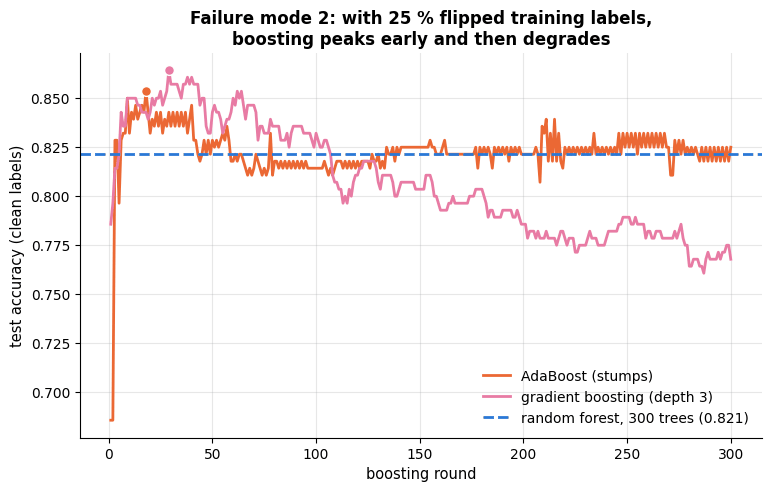

AdaBoost:          peak 0.854 at round 18, final 0.825
gradient boosting: peak 0.864 at round 29, final 0.768
random forest:     0.821 — flat, no round to choose


In [39]:
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier

X_n, y_n = make_classification(n_samples=800, n_features=10, n_informative=5, n_redundant=2,
                               flip_y=0.0, class_sep=1.3, random_state=RANDOM_STATE)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_n, y_n, test_size=0.35, stratify=y_n,
                                              random_state=RANDOM_STATE)
flip = rng.random(len(yn_tr)) < 0.25          # corrupt 25 % of the TRAINING labels only
yn_noisy = np.where(flip, 1 - yn_tr, yn_tr)

ada_n = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                           n_estimators=300, random_state=RANDOM_STATE).fit(Xn_tr, yn_noisy)
gb_n = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                                  random_state=RANDOM_STATE).fit(Xn_tr, yn_noisy)
rf_n = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(Xn_tr, yn_noisy)
acc_ada = [accuracy_score(yn_te, p) for p in ada_n.staged_predict(Xn_te)]
acc_gb = [accuracy_score(yn_te, p) for p in gb_n.staged_predict(Xn_te)]

fig, ax = plt.subplots(figsize=(8.8, 5))
ax.plot(range(1, 301), acc_ada, color=PALETTE[1], label="AdaBoost (stumps)")
ax.plot(range(1, 301), acc_gb, color=PALETTE[4], label="gradient boosting (depth 3)")
ax.axhline(rf_n.score(Xn_te, yn_te), color=PALETTE[0], ls="--",
           label=f"random forest, 300 trees ({rf_n.score(Xn_te, yn_te):.3f})")
for curve, col in [(acc_ada, PALETTE[1]), (acc_gb, PALETTE[4])]:
    b = int(np.argmax(curve))
    ax.scatter([b + 1], [curve[b]], color=col, s=50, zorder=5, edgecolor="white")
ax.set_xlabel("boosting round")
ax.set_ylabel("test accuracy (clean labels)")
ax.set_title("Failure mode 2: with 25 % flipped training labels,\nboosting peaks early and then degrades")
ax.legend(loc="lower right")
plt.show()
print(f"AdaBoost:          peak {max(acc_ada):.3f} at round {int(np.argmax(acc_ada)) + 1}, "
      f"final {acc_ada[-1]:.3f}")
print(f"gradient boosting: peak {max(acc_gb):.3f} at round {int(np.argmax(acc_gb)) + 1}, "
      f"final {acc_gb[-1]:.3f}")
print(f"random forest:     {rf_n.score(Xn_te, yn_te):.3f} — flat, no round to choose")

Both boosting curves climb to a peak within the first thirty rounds and then fall away as the
ensemble starts memorising the corrupted labels — gradient boosting loses ten accuracy points
between round 29 and round 300. The random forest has no such curve to read: at 0.821 it is
already level with AdaBoost's 300-round score and five points above gradient boosting's,
without a single decision on our part. **If you suspect noisy labels: prefer a forest, or
boost with early stopping, a small learning rate, shallow trees and `loss="log_loss"` (never
the exponential loss).** Note also how much of the peak performance is reached in the first
few dozen rounds — the "best round" here is early, and finding it *requires* a validation set.

## 10. Tuning guide

### 10.1 What each knob does

**Random forest / extra trees**

| Parameter | Controls | Range / scale | Effect of increasing | Default |
|---|---|---|---|---|
| `n_estimators` | ensemble size | 100–1000, linear | variance ↓, then flat; cost ↑ | 100 |
| `max_features` | decorrelation | 1 … $d$, or `"sqrt"`, `"log2"`, float; log-ish | $\rho$ ↑, single-tree bias ↓ | `"sqrt"` (clf) / 1.0 (reg) |
| `max_depth` | tree size | 3 … ∞ | variance ↑, bias ↓ | `None` (fully grown) |
| `min_samples_leaf` | tree size | 1, 2, 5, 10, 20; log | variance ↓, bias ↑ | 1 |
| `max_samples` | bootstrap size | 0.3–1.0 | more data per tree: $\sigma^2$ ↓, $\rho$ ↑ | all $n$ |
| `class_weight` | imbalance | `None`, `"balanced"` | — | `None` |
| `n_jobs` | parallelism | −1 | wall-clock ↓ | 1 |

**Gradient boosting (`HistGradientBoosting*` names; `GradientBoosting*` in brackets)**

| Parameter | Controls | Range / scale | Effect of increasing | Default |
|---|---|---|---|---|
| `learning_rate` $\eta$ | step size | 0.01–0.3, **log** | fewer rounds needed, more overfitting risk | 0.1 |
| `max_iter` [`n_estimators`] | rounds $M$ | 100–2000, linear | bias ↓ then overfits | 100 |
| `max_leaf_nodes` [`max_depth`] | interaction order per tree | 4–63, log | bias ↓, variance ↑ | 31 [3] |
| `min_samples_leaf` | leaf size | 5–100, log | variance ↓ | 20 [1] |
| `l2_regularization` | leaf-value shrinkage | 0–10, log(1+·) | variance ↓, bias ↑ | 0 |
| `max_features` [same] | column subsampling | 0.3–1.0 | variance ↓, bias ↑ | 1.0 |
| [`subsample`] | row subsampling | 0.5–1.0 | variance ↓, faster | 1.0 |
| `early_stopping`, `n_iter_no_change`, `validation_fraction` | when to stop | — | — | `"auto"`, 10, 0.1 |
| `max_bins` | binning resolution | 32–255 | accuracy ↑ slightly, speed ↓ | 255 |

### 10.2 Tune in this order

**Random forest.** (1) Set `n_estimators` as high as your budget allows — it is not a tuning
parameter, just pay for it. (2) Tune **`max_features`**; it is the only parameter that
reliably matters. (3) If the data are noisy or $n$ is small, tune `min_samples_leaf` (try 1,
5, 20) *together with* `max_features`, since both control capacity. (4) Stop. `max_depth`,
`criterion` and `max_samples` almost never repay the search.

**Gradient boosting.** (1) Fix `learning_rate` at 0.05–0.1 and let **early stopping** choose
`max_iter` — this pair is the one real interaction, and early stopping resolves it for free.
(2) Tune **`max_leaf_nodes`** (or `max_depth`), the capacity of each tree: this is where the
accuracy is. (3) Tune `min_samples_leaf` and `l2_regularization` if the validation curve
shows overfitting. (4) Only at the end, if you have budget left, lower `learning_rate` to
0.03 and re-run with more rounds; expect a small gain for a large bill. `max_bins` is not
worth tuning.

### 10.3 `n_estimators` for a forest: watch the plateau

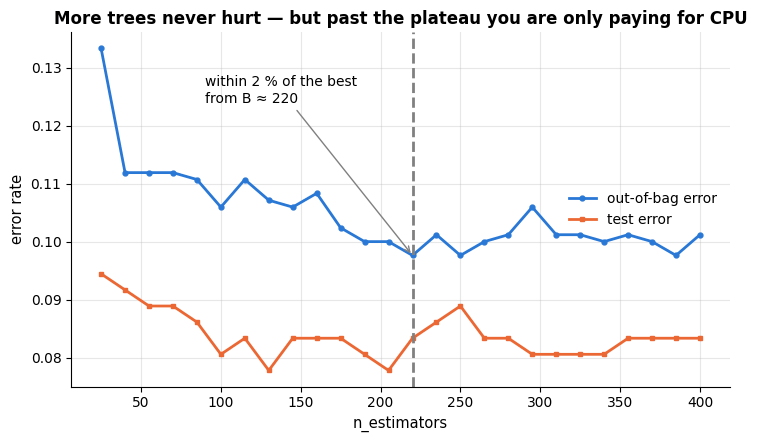

OOB error: 0.133 at B=25, 0.098 at best, 0.101 at B=400


In [40]:
Xf, yf = make_classification(n_samples=1200, n_features=20, n_informative=8, n_redundant=5,
                             flip_y=0.03, class_sep=1.0, random_state=RANDOM_STATE)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.3, stratify=yf,
                                              random_state=RANDOM_STATE)

forest = RandomForestClassifier(n_estimators=25, warm_start=True, oob_score=True,
                                random_state=RANDOM_STATE)
sizes, oob_err, test_err = [], [], []
for B in range(25, 401, 15):      # below ~25 trees some samples are in-bag everywhere and have no OOB score
    forest.set_params(n_estimators=B).fit(Xf_tr, yf_tr)     # warm_start: only the new trees are grown
    sizes.append(B)
    oob_err.append(1 - forest.oob_score_)
    test_err.append(1 - forest.score(Xf_te, yf_te))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(sizes, oob_err, marker="o", ms=3.5, color=PALETTE[0], label="out-of-bag error")
ax.plot(sizes, test_err, marker="s", ms=3.5, color=PALETTE[1], label="test error")
oob_arr = np.array(oob_err)
idx = int(np.argmax(oob_arr <= oob_arr.min() * 1.02))
plateau = sizes[idx]
ax.axvline(plateau, color="gray", ls="--")
ax.annotate(f"within 2 % of the best\nfrom B ≈ {plateau}", xy=(plateau, oob_arr[idx]),
            xytext=(plateau - 130, oob_arr.max() * 0.93), arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("n_estimators")
ax.set_ylabel("error rate")
ax.set_title("More trees never hurt — but past the plateau you are only paying for CPU")
ax.legend(loc="center right")
plt.show()
print(f"OOB error: {oob_arr[0]:.3f} at B={sizes[0]}, {oob_arr.min():.3f} at best, "
      f"{oob_arr[-1]:.3f} at B={sizes[-1]}")

Two observations. The error collapses over the first fifty trees and then wanders inside a
band about half a percentage point wide — that wandering is Monte-Carlo noise, not learning, so
there is no "optimal" `n_estimators` to find. And the out-of-bag curve sits *above* the test
curve throughout: the pessimism predicted in section 2.5, because each sample's OOB prediction
uses only the ~37 % of trees that did not see it.

### 10.4 `max_features` and `min_samples_leaf`: proper validation curves

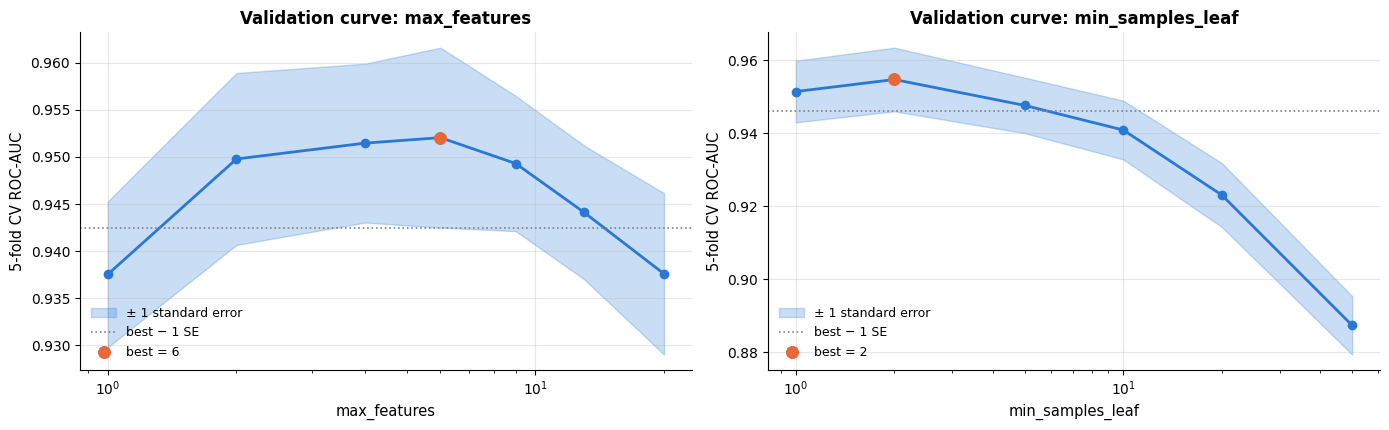

max_features: best 6 (AUC 0.9521); within 1 SE: [2, 4, 6, 9, 13]


In [41]:
cv5f = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
mf_values = [1, 2, 4, 6, 9, 13, 20]
means, ses = [], []
for mf in mf_values:
    s = cross_val_score(RandomForestClassifier(n_estimators=120, max_features=mf,
                                               random_state=RANDOM_STATE),
                        Xf_tr, yf_tr, cv=cv5f, scoring="roc_auc")
    means.append(s.mean())
    ses.append(s.std(ddof=1) / np.sqrt(5))
means, ses = np.array(means), np.array(ses)

leaf_values = [1, 2, 5, 10, 20, 50]
lmeans, lses = [], []
for ml in leaf_values:
    s = cross_val_score(RandomForestClassifier(n_estimators=120, min_samples_leaf=ml,
                                               random_state=RANDOM_STATE),
                        Xf_tr, yf_tr, cv=cv5f, scoring="roc_auc")
    lmeans.append(s.mean())
    lses.append(s.std(ddof=1) / np.sqrt(5))
lmeans, lses = np.array(lmeans), np.array(lses)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, xs, m, se, name, log in [(axes[0], mf_values, means, ses, "max_features", True),
                                 (axes[1], leaf_values, lmeans, lses, "min_samples_leaf", True)]:
    ax.plot(xs, m, marker="o", color=PALETTE[0])
    ax.fill_between(xs, m - se, m + se, alpha=0.25, color=PALETTE[0], label="± 1 standard error")
    best = int(np.argmax(m))
    # one-standard-error rule: the simplest model within 1 SE of the best
    thresh = m[best] - se[best]
    ax.axhline(thresh, color="gray", ls=":", lw=1.2, label="best − 1 SE")
    ax.scatter([xs[best]], [m[best]], color=PALETTE[1], s=70, zorder=5, label=f"best = {xs[best]}")
    if log:
        ax.set_xscale("log")
    ax.set_xlabel(name)
    ax.set_ylabel("5-fold CV ROC-AUC")
    ax.set_title(f"Validation curve: {name}")
    ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()
print(f"max_features: best {mf_values[int(np.argmax(means))]} (AUC {means.max():.4f}); "
      f"within 1 SE: {[v for v, mm in zip(mf_values, means) if mm >= means.max() - ses[int(np.argmax(means))]]}")

> **Practical note.** If the best value sits at the *edge* of the grid, extend the grid — you
> have not found the optimum, you have found the boundary. If the curve is flat within one
> standard error (as `min_samples_leaf` often is), apply the **one-standard-error rule** and
> take the simpler model: the larger `min_samples_leaf`, the smaller `max_features`.

### 10.5 The interaction that matters: `learning_rate` × `n_estimators`

For boosting, the two central parameters cannot be tuned separately. We map the whole surface
cheaply: for each learning rate we fit **one** model per fold with the maximum number of
rounds and read every smaller ensemble off `staged_predict`.

25 fits of 300 trees in 12s


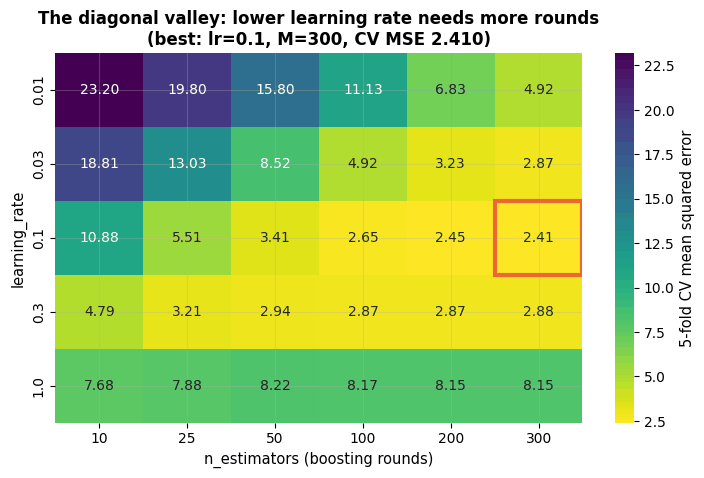

In [42]:
lrs = [0.01, 0.03, 0.1, 0.3, 1.0]
round_grid = [10, 25, 50, 100, 200, 300]
n_max2 = max(round_grid)
kf5 = KFold(5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.perf_counter()
heat = np.zeros((len(lrs), len(round_grid)))
for i, eta in enumerate(lrs):
    fold_curves = []
    for tr, va in kf5.split(X_g):
        model = GradientBoostingRegressor(n_estimators=n_max2, learning_rate=eta, max_depth=3,
                                          random_state=RANDOM_STATE).fit(X_g[tr], y_g[tr])
        errs = [mean_squared_error(y_g[va], p) for p in model.staged_predict(X_g[va])]
        fold_curves.append([errs[m - 1] for m in round_grid])
    heat[i] = np.mean(fold_curves, axis=0)
print(f"{len(lrs) * 5} fits of {n_max2} trees in {time.perf_counter() - t0:.0f}s")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="viridis_r",
            xticklabels=round_grid, yticklabels=lrs, ax=ax,
            cbar_kws={"label": "5-fold CV mean squared error"})
bi, bj = np.unravel_index(heat.argmin(), heat.shape)
ax.add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False, edgecolor=PALETTE[1], lw=3))
ax.set_xlabel("n_estimators (boosting rounds)")
ax.set_ylabel("learning_rate")
ax.set_title("The diagonal valley: lower learning rate needs more rounds\n"
             f"(best: lr={lrs[bi]}, M={round_grid[bj]}, CV MSE {heat.min():.3f})")
plt.show()

The good region is a **diagonal valley**: every learning rate has its own optimal number of
rounds, and $\eta \cdot M$ is roughly constant along the floor of the valley. The top-left
corner (small $\eta$, few rounds) is underfitted; the bottom-right corner (large $\eta$, many
rounds) is overfitted. Tuning either parameter with the other fixed at a bad value finds a
bad answer — which is why early stopping, which resolves $M$ automatically for any $\eta$, is
the right tool.

### 10.6 Tree capacity and $L_2$ regularisation

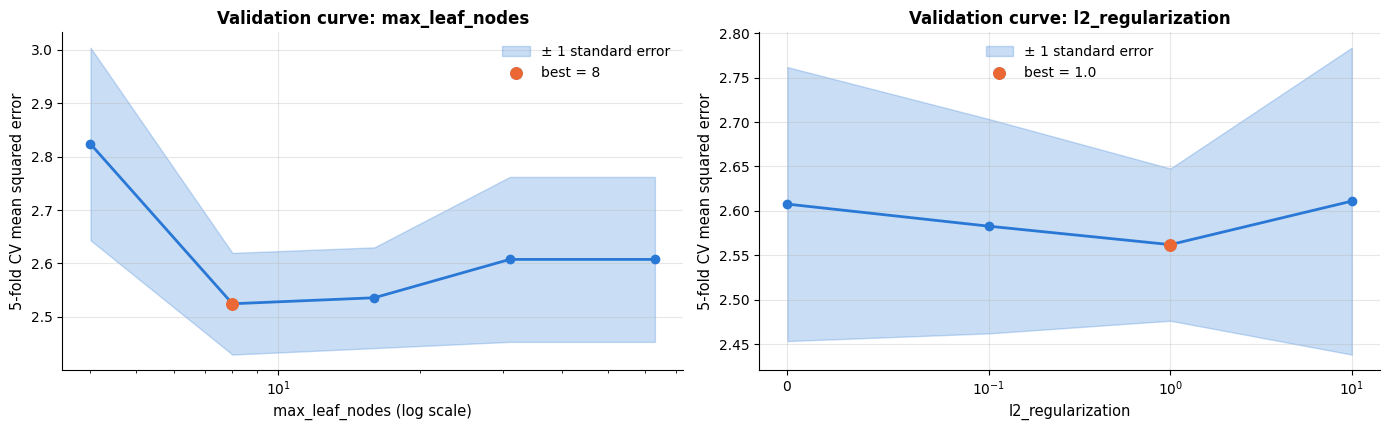

In [43]:
from sklearn.model_selection import cross_validate

leaf_grid = [4, 8, 16, 31, 63]
l2_grid = [0.0, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, grid, pname, xlabel in [(axes[0], leaf_grid, "max_leaf_nodes", "max_leaf_nodes (log scale)"),
                                (axes[1], l2_grid, "l2_regularization", "l2_regularization")]:
    m, se = [], []
    for v in grid:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=False,
                                              max_iter=100, **{pname: v})
        r = cross_validate(model, X_g, y_g, cv=kf5, scoring="neg_mean_squared_error")
        m.append(-r["test_score"].mean())
        se.append(r["test_score"].std(ddof=1) / np.sqrt(5))
    m, se = np.array(m), np.array(se)
    ax.plot(grid, m, marker="o", color=PALETTE[0])
    ax.fill_between(grid, m - se, m + se, alpha=0.25, color=PALETTE[0], label="± 1 standard error")
    best = int(np.argmin(m))
    ax.scatter([grid[best]], [m[best]], color=PALETTE[1], s=70, zorder=5, label=f"best = {grid[best]}")
    if pname == "max_leaf_nodes":
        ax.set_xscale("log")
    else:
        ax.set_xscale("symlog", linthresh=0.1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("5-fold CV mean squared error")
    ax.set_title(f"Validation curve: {pname}")
    ax.legend()
plt.tight_layout()
plt.show()

`max_leaf_nodes` is the capacity knob: a tree with $L$ leaves can express interactions of
order up to $\log_2 L$, so 4 leaves means "pairs of features at most" and 63 leaves means
"six-way interactions". `l2_regularization` shrinks the leaf values; on clean data its curve
is flat, on noisy data it helps. Both curves are worth *looking* at before deciding to tune.

### 10.7 Early stopping: let the model choose $M$

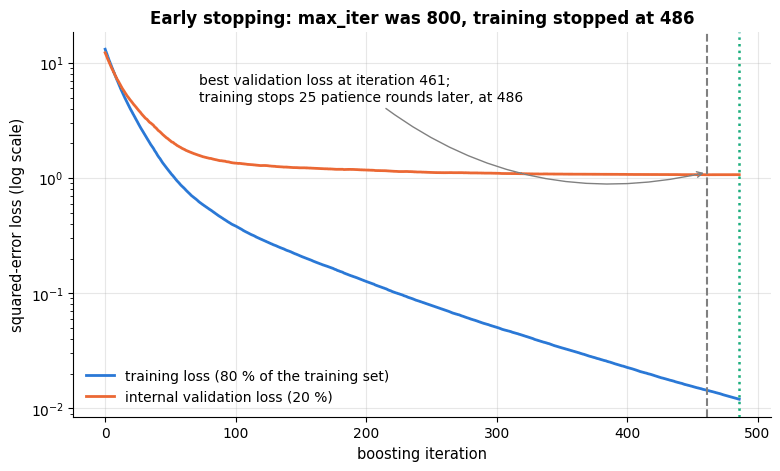

n_iter_ = 486 of max_iter = 800;  best internal validation at iteration 461
held-out test MSE with early stopping: 2.494


In [44]:
hgb_es = HistGradientBoostingRegressor(max_iter=800, learning_rate=0.05, early_stopping=True,
                                       validation_fraction=0.2, n_iter_no_change=25,
                                       scoring="loss", random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
train_loss = -np.asarray(hgb_es.train_score_)          # scores are negative losses
val_loss = -np.asarray(hgb_es.validation_score_)
best_iter = int(np.argmin(val_loss))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_loss, color=PALETTE[0], label="training loss (80 % of the training set)")
ax.plot(val_loss, color=PALETTE[1], label="internal validation loss (20 %)")
ax.axvline(best_iter, color="gray", ls="--", lw=1.5)
ax.axvline(hgb_es.n_iter_, color=PALETTE[2], ls=":", lw=1.8)
ax.annotate(f"best validation loss at iteration {best_iter};\n"
            f"training stops {hgb_es.n_iter_ - best_iter} patience rounds later, at {hgb_es.n_iter_}",
            xy=(best_iter, val_loss[best_iter] * 1.05), xytext=(0.18, 0.82),
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="gray", connectionstyle="arc3,rad=0.25"))
ax.set_yscale("log")
ax.set_xlabel("boosting iteration")
ax.set_ylabel("squared-error loss (log scale)")
ax.set_title(f"Early stopping: max_iter was 800, training stopped at {hgb_es.n_iter_}")
ax.legend()
plt.show()
print(f"n_iter_ = {hgb_es.n_iter_} of max_iter = 800;  best internal validation at iteration {best_iter}")
print(f"held-out test MSE with early stopping: {mean_squared_error(yg_te, hgb_es.predict(Xg_te)):.3f}")

Early stopping keeps a slice of the training data aside (`validation_fraction`), watches the
loss on it after every round, and stops when it has not improved for `n_iter_no_change`
rounds. For classification with imbalanced classes set `scoring="roc_auc"` (or another metric)
instead of `"loss"`, and remember that the internal split is *not* stratified by default in
older versions — check, or do your own early stopping on an explicit validation set.

## 11. Case study: real data, honest comparison

Everything so far used generators whose truth we knew. Now a **real** dataset with all its
idiosyncrasies: the breast cancer Wisconsin data (Street, Wolberg & Mangasarian, 1993) — 569
tumours, 30 features computed from digitised images of fine-needle aspirates, target
malignant/benign. It is small, clean and low-dimensional, and — as we will see — that matters
a great deal for which model wins.

In [45]:
X_bc, y_bc = cancer.data, cancer.target
print(f"{X_bc.shape[0]} samples, {X_bc.shape[1]} features; {y_bc.mean():.1%} benign")
Xbc_tv, Xbc_test, ybc_tv, ybc_test = train_test_split(X_bc, y_bc, test_size=0.2, stratify=y_bc,
                                                      random_state=RANDOM_STATE)
print(f"train+validation {Xbc_tv.shape[0]} rows, test {Xbc_test.shape[0]} rows (touched once, at the end)")
X_bc.describe().T[["mean", "std", "min", "max"]].head(6).round(2)

569 samples, 30 features; 62.7% benign
train+validation 455 rows, test 114 rows (touched once, at the end)


,mean,std,min,max
mean radius,14.13,3.52,6.98,28.11
mean texture,19.29,4.30,9.71,39.28
mean perimeter,91.97,24.30,43.79,188.50
mean area,654.89,351.91,143.50,2501.00
mean smoothness,0.10,0.01,0.05,0.16
mean compactness,0.10,0.05,0.02,0.35


### 11.1 The comparison table

Baseline first, then a single tree, then the ensembles — each scored by 5-fold CV on the
train+validation portion only, reported as mean ± standard error together with the mean fit
time. ROC-AUC is the right metric here: the classes are imbalanced 63/37 and the clinical
question is ranking risk, not a fixed threshold (notebook 7 discusses the choice of metric).

In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier

candidates = {
    "baseline (majority class)": DummyClassifier(strategy="most_frequent"),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "single decision tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "random forest (300)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "extra trees (300)": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "hist. gradient boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
rows = []
for name, model in candidates.items():
    res = cross_validate(model, Xbc_tv, ybc_tv, cv=cv5, scoring=["roc_auc", "accuracy"],
                         return_train_score=False)
    rows.append({"model": name,
                 "CV ROC-AUC": res["test_roc_auc"].mean(),
                 "SE": res["test_roc_auc"].std(ddof=1) / np.sqrt(5),
                 "CV accuracy": res["test_accuracy"].mean(),
                 "fit time (s)": res["fit_time"].mean()})
bc_table = pd.DataFrame(rows).set_index("model").sort_values("CV ROC-AUC", ascending=False)
bc_table.round(4)

,CV ROC-AUC,SE,CV accuracy,fit time (s)
model,,,,
logistic regression,0.9959,0.0025,0.9780,0.0047
extra trees (300),0.9938,0.0022,0.9736,0.2668
hist. gradient boosting,0.9933,0.0017,0.9692,0.1234
random forest (300),0.9904,0.0036,0.9648,0.4098
single decision tree,0.9179,0.0100,0.9165,0.0057
baseline (majority class),0.5000,0.0000,0.6264,0.0006


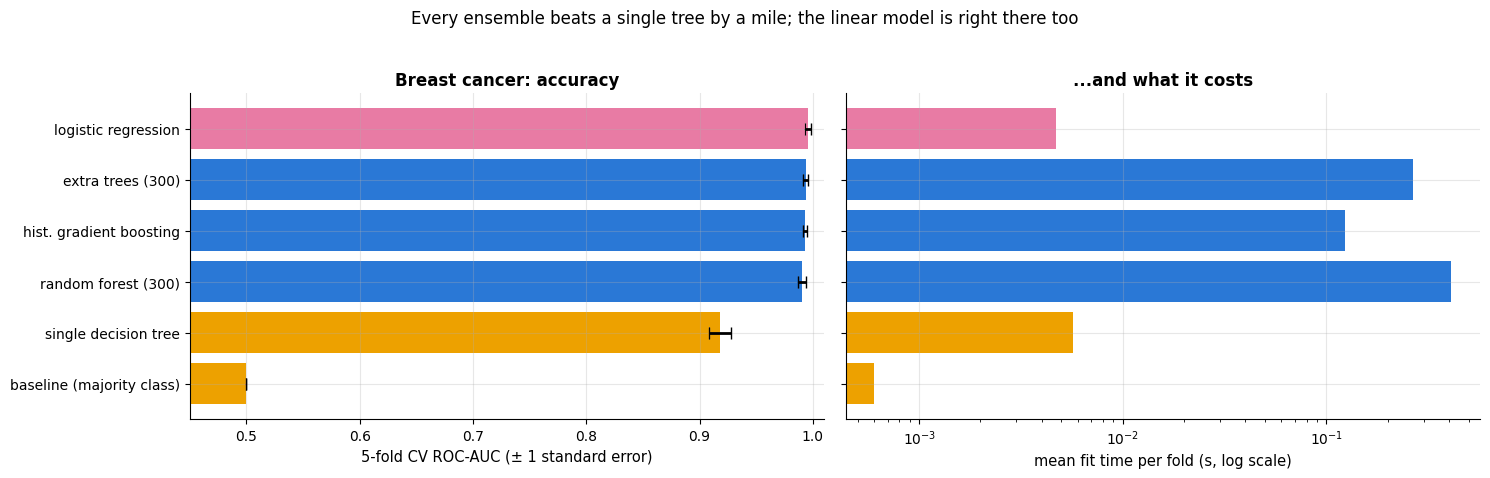

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
order = bc_table.sort_values("CV ROC-AUC").index
cols = [PALETTE[3] if "baseline" in o or "single" in o else
        (PALETTE[4] if "logistic" in o else PALETTE[0]) for o in order]
axes[0].barh(order, bc_table.loc[order, "CV ROC-AUC"], xerr=bc_table.loc[order, "SE"],
             color=cols, capsize=4)
axes[0].set_xlim(0.45, 1.01)
axes[0].set_xlabel("5-fold CV ROC-AUC (± 1 standard error)")
axes[0].set_title("Breast cancer: accuracy")
axes[1].barh(order, bc_table.loc[order, "fit time (s)"], color=cols)
axes[1].set_xscale("log")
axes[1].set_xlabel("mean fit time per fold (s, log scale)")
axes[1].set_title("...and what it costs")
axes[1].tick_params(labelleft=False)
fig.suptitle("Every ensemble beats a single tree by a mile; the linear model is right there too",
             y=1.03)
plt.tight_layout()
plt.show()

Read the error bars before reading the ranking. The ensembles all sit within a standard error
or two of one another, and — the honest headline — **a plain logistic regression is at least
as good as any of them here, at a thousandth of the cost.** That is not a bug in the
experiment; it is section 7's lesson arriving in real life. With $n = 455$, $d = 30$ smooth
geometric measurements, and a target that is close to linearly separable in those features,
the linear model's inductive bias is the correct one. The single decision tree, by contrast,
is far behind everything — which is exactly why this notebook exists.

### 11.2 The same exercise for regression

diabetes: 442 patients, 10 features; target = disease progression after one year, range 25–346


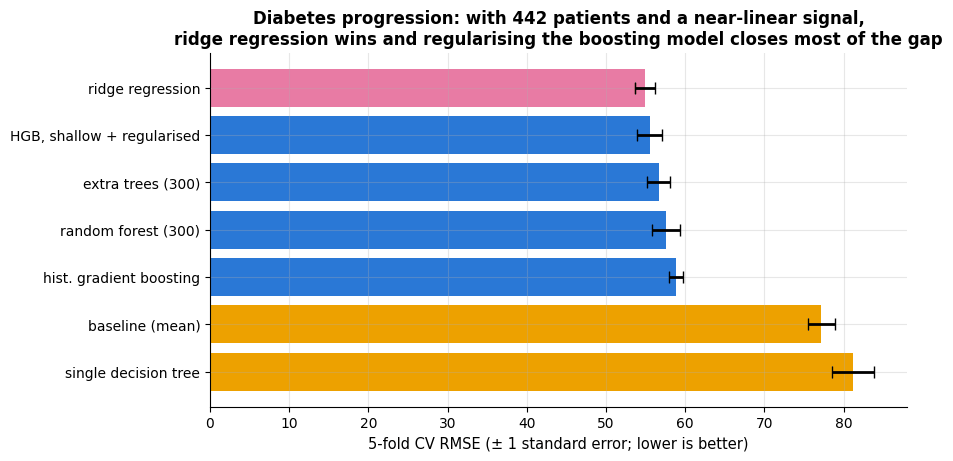

,CV RMSE,SE,fit time (s)
model,,,
ridge regression,54.897,1.269,0.005
"HGB, shallow + regularised",55.512,1.621,0.040
extra trees (300),56.669,1.474,0.368
random forest (300),57.553,1.766,0.526
hist. gradient boosting,58.890,0.875,0.075
baseline (mean),77.193,1.679,0.001
single decision tree,81.198,2.677,0.004


In [48]:
from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor as ETR

diabetes = load_diabetes(as_frame=True)
X_db, y_db = diabetes.data, diabetes.target
print(f"diabetes: {X_db.shape[0]} patients, {X_db.shape[1]} features; "
      f"target = disease progression after one year, range {y_db.min():.0f}–{y_db.max():.0f}")

reg_candidates = {
    "baseline (mean)": DummyRegressor(strategy="mean"),
    "ridge regression": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25))),
    "single decision tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "random forest (300)": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "extra trees (300)": ETR(n_estimators=300, random_state=RANDOM_STATE),
    "hist. gradient boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "HGB, shallow + regularised": HistGradientBoostingRegressor(max_leaf_nodes=4, learning_rate=0.05,
                                                                min_samples_leaf=20, l2_regularization=1.0,
                                                                random_state=RANDOM_STATE),
}
rows = []
for name, model in reg_candidates.items():
    res = cross_validate(model, X_db, y_db, cv=kf5, scoring="neg_root_mean_squared_error")
    rows.append({"model": name, "CV RMSE": -res["test_score"].mean(),
                 "SE": res["test_score"].std(ddof=1) / np.sqrt(5),
                 "fit time (s)": res["fit_time"].mean()})
db_table = pd.DataFrame(rows).set_index("model").sort_values("CV RMSE")

fig, ax = plt.subplots(figsize=(9, 4.6))
order = db_table.sort_values("CV RMSE", ascending=False).index
ax.barh(order, db_table.loc[order, "CV RMSE"], xerr=db_table.loc[order, "SE"],
        color=[PALETTE[3] if ("baseline" in o or "single" in o) else
               (PALETTE[4] if "ridge" in o else PALETTE[0]) for o in order], capsize=4)
ax.set_xlabel("5-fold CV RMSE (± 1 standard error; lower is better)")
ax.set_title("Diabetes progression: with 442 patients and a near-linear signal,\n"
             "ridge regression wins and regularising the boosting model closes most of the gap")
plt.show()
db_table.round(3)

Same story, more sharply: on 442 patients the ridge model is the best predictor, the untuned
boosting model is worse than the forest, and *regularising* the boosting model (four leaves,
small learning rate, larger leaves, a little $L_2$) recovers most of the difference. Small
data means shallow trees.

### 11.3 Tuning and the final test score

We follow the order from section 10.2 on the breast cancer data: learning rate fixed, rounds
by early stopping, then `max_leaf_nodes`.

grid search: 9 configurations x 5 folds
best parameters: {'max_leaf_nodes': 4, 'min_samples_leaf': 10}
best CV ROC-AUC: 0.9927 (untuned default was 0.9933)


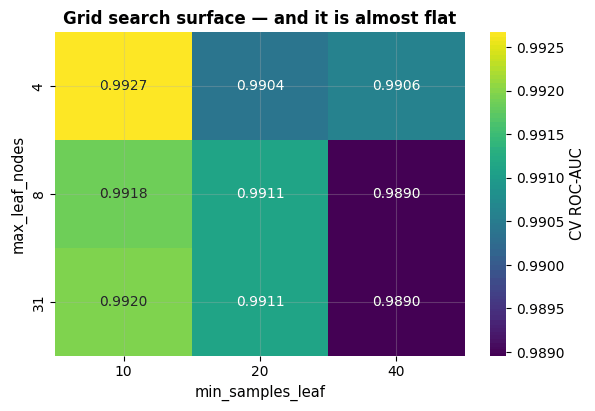

In [49]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    HistGradientBoostingClassifier(learning_rate=0.06, max_iter=500, early_stopping=True,
                                   n_iter_no_change=20, validation_fraction=0.15,
                                   random_state=RANDOM_STATE),
    param_grid={"max_leaf_nodes": [4, 8, 31], "min_samples_leaf": [10, 20, 40]},
    cv=cv5, scoring="roc_auc", n_jobs=1)
search.fit(Xbc_tv, ybc_tv)
print(f"grid search: {len(search.cv_results_['params'])} configurations x 5 folds")
print(f"best parameters: {search.best_params_}")
print(f"best CV ROC-AUC: {search.best_score_:.4f} "
      f"(untuned default was {bc_table.loc['hist. gradient boosting', 'CV ROC-AUC']:.4f})")

cvres = pd.DataFrame(search.cv_results_)
pivot = cvres.pivot_table(index="param_max_leaf_nodes", columns="param_min_samples_leaf",
                          values="mean_test_score")
fig, ax = plt.subplots(figsize=(6.6, 4.2))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax,
            cbar_kws={"label": "CV ROC-AUC"})
ax.set_title("Grid search surface — and it is almost flat")
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_leaf_nodes")
plt.show()

Two things are worth noticing, and neither is the "best parameters" line. First, **the whole
surface is flat**: every cell is within a couple of standard errors of every other, so the
"winner" is largely noise. Second, and more embarrassing, the tuned score is not better than
the untuned default. That happens regularly on small, easy datasets, and it is the reason
section 10.2 says to spend the budget on *one or two* parameters and stop. A search that
returns a flat surface has told you something useful — that this model is insensitive here —
and the right response is to take the cheapest configuration in the flat region (`max_leaf_nodes=4`
is both the simplest and the fastest) and move on.

logistic regression    test ROC-AUC 0.9954  test accuracy 0.9825
random forest (300)    test ROC-AUC 0.9937  test accuracy 0.9474
tuned boosting         test ROC-AUC 0.9897  test accuracy 0.9649


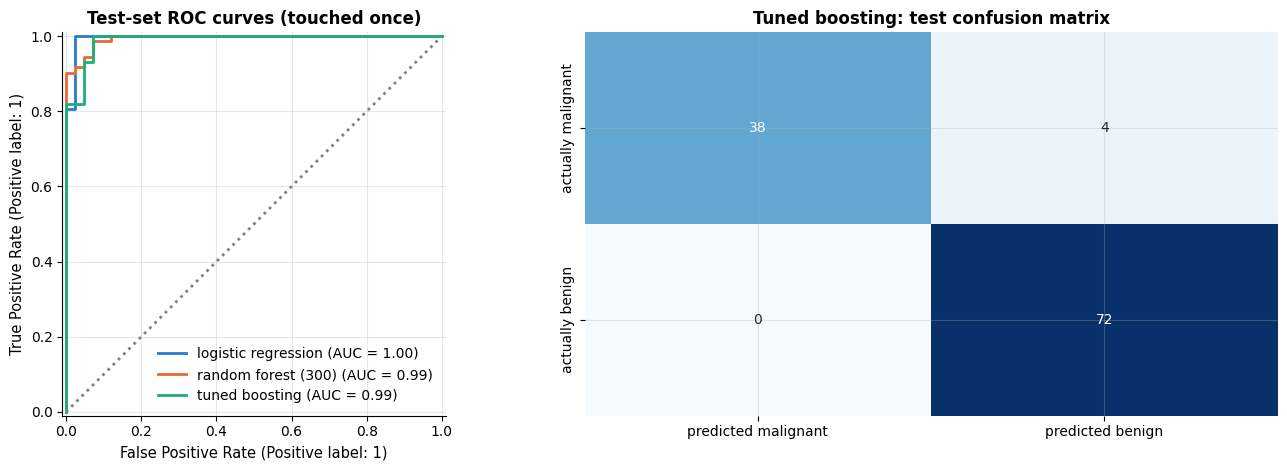

In [50]:
from sklearn.metrics import roc_auc_score, confusion_matrix, RocCurveDisplay

finalists = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "random forest (300)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "tuned boosting": search.best_estimator_,
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for i, (name, model) in enumerate(finalists.items()):
    model.fit(Xbc_tv, ybc_tv)
    proba = model.predict_proba(Xbc_test)[:, 1]
    RocCurveDisplay.from_predictions(ybc_test, proba, ax=axes[0], name=name,
                                     curve_kwargs={"color": PALETTE[i]})
    print(f"{name:22s} test ROC-AUC {roc_auc_score(ybc_test, proba):.4f}  "
          f"test accuracy {model.score(Xbc_test, ybc_test):.4f}")
axes[0].plot([0, 1], [0, 1], ls=":", color="gray")
axes[0].set_title("Test-set ROC curves (touched once)")
cm = confusion_matrix(ybc_test, finalists["tuned boosting"].predict(Xbc_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False,
            xticklabels=["predicted malignant", "predicted benign"],
            yticklabels=["actually malignant", "actually benign"])
axes[1].set_title("Tuned boosting: test confusion matrix")
plt.tight_layout()
plt.show()

All three models land between 0.99 and 1.00 test ROC-AUC on 114 patients — which, with only
42 malignant cases in the test set, means the differences between them are not measurable.
This is the moment to resist the temptation to declare a winner: the honest report is *"three
models, statistically indistinguishable, and we would ship the simplest"*. Note also that we
looked at the test set exactly once, after all decisions were made. Going back now to pick the
model with the best *test* score would quietly turn the test set into a second validation set
(notebook 5, section 4.4).

The confusion matrix carries a warning that the AUC hides. At the default 0.5 threshold the
model calls four genuinely malignant tumours benign while producing no false alarms at all —
a threshold tuned for *accuracy* on a 63/37 split, not for the cost structure of the problem,
where a missed malignancy is far worse than an unnecessary biopsy. Moving the threshold down
trades those misses for false alarms one at a time; notebook 7 shows how to choose the
operating point from the precision–recall curve and the relative costs.

### 11.4 Interpreting the fitted model

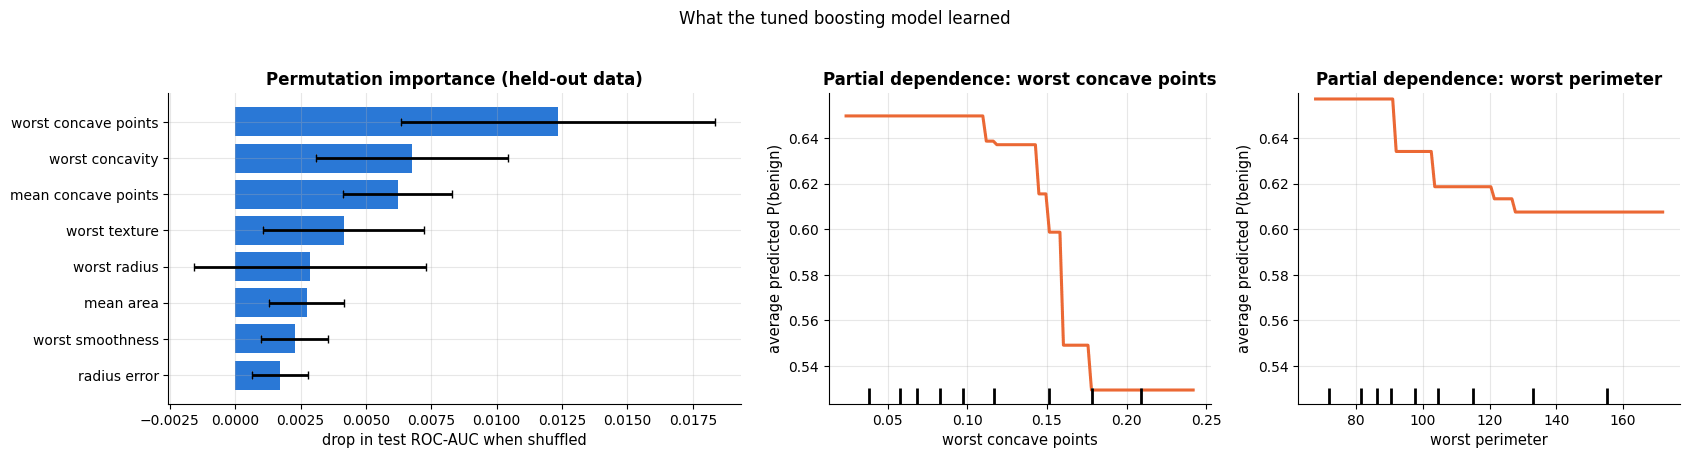

In [51]:
from sklearn.inspection import PartialDependenceDisplay

best_model = finalists["tuned boosting"]
perm_bc = permutation_importance(best_model, Xbc_test, ybc_test, n_repeats=15,
                                 scoring="roc_auc", random_state=RANDOM_STATE)
top = np.argsort(perm_bc.importances_mean)[::-1][:8][::-1]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), gridspec_kw={"width_ratios": [1.5, 1, 1]})
axes[0].barh(X_bc.columns[top], perm_bc.importances_mean[top],
             xerr=perm_bc.importances_std[top], color=PALETTE[0], capsize=3)
axes[0].set_xlabel("drop in test ROC-AUC when shuffled")
axes[0].set_title("Permutation importance (held-out data)")
PartialDependenceDisplay.from_estimator(best_model, Xbc_tv,
                                        ["worst concave points", "worst perimeter"],
                                        method="brute",          # "recursion" would return log-odds
                                        response_method="predict_proba",
                                        ax=[axes[1], axes[2]], line_kw={"color": PALETTE[1], "lw": 2.2})
axes[1].set_title("Partial dependence: worst concave points")
axes[2].set_title("Partial dependence: worst perimeter")
for ax in (axes[1], axes[2]):
    ax.set_ylabel("average predicted P(benign)")
fig.suptitle("What the tuned boosting model learned", y=1.03)
plt.tight_layout()
plt.show()

The model rests on a handful of "worst" (largest-nucleus) measurements — concave points,
concavity, texture — and both partial dependence curves fall monotonically: the larger and more
concave the worst nuclei, the lower the predicted probability of a benign tumour. That is the
direction the original paper's clinical reasoning predicts, and reproducing it is the minimum
one should demand of a model before trusting it.

> **Warning — read partial dependence carefully.** Two traps are visible in this very figure.
> (i) *Which scale?* For tree ensembles scikit-learn defaults to `method="recursion"`, which is
> fast but returns values on the **decision-function (log-odds) scale**; we asked for
> `method="brute"` with `response_method="predict_proba"`, so the axis really is an average
> predicted probability. (ii) *Correlated features flatten the curve.* The vertical range is
> only about 0.65 → 0.53, far less dramatic than the story suggests, because partial dependence
> forces one feature to a value while leaving the others untouched — and "worst radius", "worst
> perimeter" and "worst area" are nearly the same measurement three times over. Setting the
> concave-point count low while the nucleus stays huge is a combination that never occurs in
> nature, and the model quite reasonably keeps calling those points malignant. Notebook 17
> develops the alternatives (ICE curves, SHAP, grouped importances).

> **What you would tell a non-technical stakeholder.** *"On 114 patients the model had never
> seen, it ranks tumours by risk almost perfectly: roughly 99 times out of 100, if you hand it
> one malignant and one benign sample it will score the malignant one as more suspicious. It
> is not magic: it re-discovers
> what pathologists already use, namely the size and irregularity of the largest cell nuclei.
> A simple logistic regression does the same job here, and it is easier to audit, so I would
> deploy that and keep the boosting model as a cross-check. Neither should be used without a
> pathologist in the loop: 114 test patients is a small sample, and the data come from one
> hospital in one decade."*

## Summary

- Ensembles work because the variance of an average of $B$ predictors with variance $\sigma^2$
  and pairwise correlation $\rho$ is $\rho\sigma^2 + (1-\rho)\sigma^2/B$. More members remove
  the second term; only *decorrelation* touches the first. Averaging leaves bias unchanged.
- **Bagging** fits the base learner on bootstrap samples and averages. About $e^{-1} \approx
  36.8$ % of the data is out-of-bag for each member, giving a free validation estimate that
  tracks test error.
- **Random forests** add per-split feature subsampling (`max_features`) to reduce $\rho$ at
  the cost of a worse individual tree; the optimum is interior. **Extra trees** randomise the
  split thresholds too — faster, sometimes better.
- Impurity-based feature importance is biased towards high-cardinality features; use
  `permutation_importance` on held-out data.
- **AdaBoost** reweights misclassified points exponentially and is exactly forward stagewise
  fitting of the exponential loss — which is also why it breaks on noisy labels.
- **Gradient boosting** is gradient descent in function space: fit a shallow tree to the
  pseudo-residuals, add $\eta$ times it, repeat. Squared loss gives ordinary residuals, log
  loss gives $y - p$. `HistGradientBoosting*` bins the features and is one to two orders of
  magnitude faster, with native NaN and categorical support.
- The number of rounds is a *tuning* parameter for boosting (use early stopping) and a
  *budget* parameter for forests (more is never worse). `learning_rate` and `n_estimators`
  trade off along a diagonal valley; tune everything else only after those two.
- **Voting** combines different models with a fixed rule, **stacking** learns the rule from
  cross-fitted out-of-fold predictions. Both help in proportion to how *differently* the base
  models fail, and both cost several times a single fit for a fraction of a percent.
- Neither family extrapolates, and boosting overfits label noise. Trees beat linear models
  when the target has interactions and thresholds, not merely because the data are in a table.

| Situation | Reach for |
|---|---|
| A strong result in one line, no tuning | `RandomForestClassifier(n_estimators=500, n_jobs=-1)` |
| The best accuracy on a table | `HistGradientBoosting*` + early stopping, then tune `max_leaf_nodes` |
| Mixed types, missing values, no time for preprocessing | `HistGradientBoosting*` with `categorical_features="from_dtype"` |
| Noisy or partly mislabelled targets | random forest, or boosting with small $\eta$ + early stopping |
| Need to extrapolate a trend | a linear/additive model, or trees on detrended residuals |
| Very large $n$, many features | `HistGradientBoosting*`, LightGBM, or extra trees |
| A free validation estimate | `oob_score=True` on a forest |
| Squeezing out the last 0.2 % | `StackingClassifier` over diverse base models |
| Few rows, smooth signal | a regularised linear model — see section 11 |

**Next steps:** notebook 11 (support vector machines) presents a very different inductive
bias for the same problems; notebook 12 (model selection and hyper-parameter tuning) scales
the searches of section 10 up with random search, successive halving and nested CV;
notebook 17 (interpretability) develops permutation importance, partial dependence and SHAP
for exactly the models built here.

## Exercises

### Exercise 1 — Out-of-bag by hand (easy)
Without using `oob_score=True`, fit a `RandomForestRegressor(n_estimators=200, bootstrap=True)`
on `X_train, y_train` and reconstruct the out-of-bag predictions yourself. scikit-learn
exposes the bootstrap indices through `sklearn.ensemble._forest._generate_sample_indices`, but
you can avoid private API by refitting your own `BaggedTrees`. Compare your OOB $R^2$ with the
test $R^2$ and with `oob_score_`.

<details><summary>Solution sketch</summary>

Reuse the `BaggedTrees` class from section 2.2: it already stores `oob_masks_`. The OOB
prediction for sample $i$ averages `trees_[b].predict(X[i])` over the $b$ with
`oob_masks_[b, i] == True`; with $B = 200$ that is about 74 trees per sample. Expect
`oob_score_` within ±0.02 of the test $R^2$, slightly pessimistic.
</details>

### Exercise 2 — `max_features` on a real dataset (easy)
Run a `max_features` validation curve (5-fold CV, ROC-AUC, ± 1 SE) for a random forest on
`load_wine` or `load_breast_cancer`. Is the optimum interior, or at an edge? Does the
one-standard-error rule change your choice?

<details><summary>Solution sketch</summary>

```py
means = [cross_val_score(RandomForestClassifier(n_estimators=200, max_features=m,
                                                random_state=42), X, y, cv=cv, scoring="roc_auc").mean()
         for m in [1, 2, 3, 5, 8, 13, 20, 30]]
```
On breast cancer the curve is very flat above `max_features=2`; almost every value is within
one standard error of the best, so take the smallest (fastest) one. Flat curves are the normal
case for forests — which is why `max_features` is the *only* forest parameter worth a search.
</details>

### Exercise 3 — Gradient boosting with the log loss (medium)
Extend `gb_fit` to binary classification. Initialise
$F_0 = \log\frac{\bar y}{1 - \bar y}$ (the log-odds of the base rate), use the pseudo-residual
$g_i = y_i - \sigma(F_i)$, and predict $P(y=1) = \sigma(F_M)$. Check your implementation
against `GradientBoostingClassifier(loss="log_loss")` on the moons data, comparing predicted
probabilities.

<details><summary>Solution sketch</summary>

```py
F = np.full(len(y), np.log(y.mean() / (1 - y.mean())))
for m in range(M):
    p = 1 / (1 + np.exp(-F))
    h = DecisionTreeRegressor(max_depth=3).fit(X, y - p)       # pseudo-residual
    F += lr * h.predict(X)
```
Your probabilities will be close but not identical: scikit-learn additionally performs a
one-step Newton update of each leaf value, replacing the mean residual $\bar g$ in a leaf by
$\bar g / \overline{p(1-p)}$. Adding that line brings the two into near-exact agreement and
is a good way to see what "line search on the leaves" means.
</details>

### Exercise 4 — The early-stopping curve (medium)
Take `HistGradientBoostingClassifier` on `load_wine` (3 classes). Plot `validation_score_`
against iteration for `learning_rate` in $\{0.02, 0.1, 0.5\}$, marking `n_iter_` on each
curve. How does the chosen number of iterations scale with the learning rate, and is the
product $\eta \cdot M$ roughly constant?

<details><summary>Solution sketch</summary>

Set `early_stopping=True, max_iter=1000, n_iter_no_change=20, validation_fraction=0.2`. You
should see $M$ roughly inversely proportional to $\eta$ (so $\eta M \approx$ const) until the
smallest learning rate hits `max_iter`. With only 178 samples the internal validation split is
tiny and the stopping point is noisy — a reminder that early stopping needs enough validation
data to be reliable.
</details>

### Exercise 5 — Stacking versus the best single model (hard)
On `load_digits` (1797 × 64), build a `StackingClassifier` over a logistic regression, a
$k$-NN, a random forest and a `HistGradientBoostingClassifier`, with a logistic-regression
meta-learner. Compare its 5-fold CV accuracy with the best single member *and* with soft
voting. Is the improvement larger than one standard error? Report the fit-time cost.

<details><summary>Solution sketch</summary>

Use `cv=3` inside `StackingClassifier` to keep the cost down and `HistGradientBoosting*` with
`max_iter=50`. Expect the stack to beat the best member by a few tenths of a percent — often
*within* one standard error, at roughly ten times the cost. That non-result is the point:
report it, and decide whether the accuracy is worth the complexity.
</details>

### Exercise 6 — Fixing the extrapolation failure (hard)
Take the linear-trend data of section 9.1 and build a hybrid: fit a `LinearRegression` first,
then a `HistGradientBoostingRegressor` on its residuals, and predict with the sum. Show that
the hybrid extrapolates correctly. Then break it: add a genuine non-linearity outside the
training range and discuss what the hybrid can and cannot know.

<details><summary>Solution sketch</summary>

```py
lin = LinearRegression().fit(x[:, None], y)
resid_model = HistGradientBoostingRegressor().fit(x[:, None], y - lin.predict(x[:, None]))
pred = lin.predict(xg) + resid_model.predict(xg)
```
The linear part carries the trend outside the training range and the boosting part contributes
a constant there, so the hybrid extrapolates along the fitted line. It cannot know about
curvature that never appeared in the data — no model can. This "linear trend + tree residuals"
pattern is standard practice for forecasting (notebook 16).
</details>

## References and further reading

### Textbooks

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. **(free)** — Chapter 8.7 (bagging), 15 (random forests, including the $\rho\sigma^2 + (1-\rho)\sigma^2/B$ derivation of section 1.2) and 10 (boosting as forward stagewise additive modelling) are the reference treatment of this notebook.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. **(free at https://www.statlearning.com)** — Chapter 8 covers the same ground at a gentler pace, with the Python labs.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. **(free)** — Chapter 18 treats ensembles from a probabilistic angle, including the connection to Bayesian model averaging.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 7 is a practical tour of every estimator used here.
- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth. — The base learner; see notebook 9.

### Papers

- Breiman, L. (1996). Bagging predictors. *Machine Learning*, 24(2), 123–140. — Introduces bagging and the out-of-bag estimate of section 2.5.
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. — The random forest, the correlation/strength analysis, and the original `max_features` advice.
- Ho, T. K. (1998). The random subspace method for constructing decision forests. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 20(8), 832–844. — Feature subsampling, independently of Breiman.
- Geurts, P., Ernst, D., & Wehenkel, L. (2006). Extremely randomized trees. *Machine Learning*, 63(1), 3–42. — Extra trees (section 3.3).
- Freund, Y., & Schapire, R. E. (1997). A decision-theoretic generalization of on-line learning and an application to boosting. *Journal of Computer and System Sciences*, 55(1), 119–139. — AdaBoost.
- Schapire, R. E., Freund, Y., Bartlett, P., & Lee, W. S. (1998). Boosting the margin: a new explanation for the effectiveness of voting methods. *The Annals of Statistics*, 26(5), 1651–1686. — The margin explanation used in section 4.5.
- Friedman, J. H., Hastie, T., & Tibshirani, R. (2000). Additive logistic regression: a statistical view of boosting. *The Annals of Statistics*, 28(2), 337–407. — AdaBoost as stagewise fitting of the exponential loss (section 4.6).
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *The Annals of Statistics*, 29(5), 1189–1232. — Gradient boosting, shrinkage, and partial dependence plots.
- Friedman, J. H. (2002). Stochastic gradient boosting. *Computational Statistics & Data Analysis*, 38(4), 367–378. — The `subsample` parameter of section 5.5.
- Friedman, J. H. (1991). Multivariate adaptive regression splines. *The Annals of Statistics*, 19(1), 1–67. — Source of the "Friedman #1" test function used throughout.
- Chen, T., & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *Proceedings of KDD 2016*, 785–794.
- Ke, G., et al. (2017). LightGBM: a highly efficient gradient boosting decision tree. *Advances in NeurIPS 30*. — Histogram binning and leaf-wise growth, the basis of `HistGradientBoosting*`.
- Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). CatBoost: unbiased boosting with categorical features. *Advances in NeurIPS 31*.
- Wolpert, D. H. (1992). Stacked generalization. *Neural Networks*, 5(2), 241–259. — Stacking (section 6).
- Dietterich, T. G. (2000). Ensemble methods in machine learning. *Multiple Classifier Systems (LNCS 1857)*, 1–15. — A short, readable survey of why ensembles work.
- Dietterich, T. G. (2000). An experimental comparison of three methods for constructing ensembles of decision trees: bagging, boosting, and randomization. *Machine Learning*, 40(2), 139–157. — The systematic study of boosting's degradation under label noise (section 9.2).
- Zhu, J., Zou, H., Rosset, S., & Hastie, T. (2009). Multi-class AdaBoost. *Statistics and Its Interface*, 2(3), 349–360. — The SAMME algorithm implemented in section 4.3.
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures. *BMC Bioinformatics*, 8, 25. — The cardinality bias demonstrated in section 3.4.
- Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? *NeurIPS 2022 Datasets and Benchmarks*. — The benchmark and the three-part diagnosis quoted in section 7.
- Caruana, R., & Niculescu-Mizil, A. (2006). An empirical comparison of supervised learning algorithms. *Proceedings of ICML 2006*, 161–168. — Large-scale comparison in which boosted trees and random forests come out on top.
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *The Annals of Statistics*, 7(1), 1–26. — The bootstrap.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The breast cancer Wisconsin data of section 11.

### Documentation and online resources

- scikit-learn user guide, *Ensembles: Gradient boosting, random forests, bagging, voting, stacking* — https://scikit-learn.org/stable/modules/ensemble.html
- scikit-learn user guide, *Permutation feature importance* — https://scikit-learn.org/stable/modules/permutation_importance.html
- scikit-learn user guide, *Partial dependence and individual conditional expectation plots* — https://scikit-learn.org/stable/modules/partial_dependence.html
- XGBoost documentation — https://xgboost.readthedocs.io/ — the "Introduction to Boosted Trees" page is an excellent derivation of the regularised objective.
- LightGBM documentation, *Parameters tuning* — https://lightgbm.readthedocs.io/en/stable/Parameters-Tuning.html
- CatBoost documentation — https://catboost.ai/docs/